In [1]:
# Cell: Image and Mask Loading Utilities

from pathlib import Path
import cv2
import numpy as np
from typing import Tuple, Dict, List, Optional
import matplotlib.pyplot as plt

# Define paths
KAGGLE_IMAGES_DIR = Path('../data/Kaggle')
KAGGLE_MASKS_DIR = Path('../data/Kaggle/predictions')


In [2]:
def load_single_image(image_name: str) -> np.ndarray:
    """
    Load a single image from Kaggle directory.
    
    Args:
        image_name: Name of the image file (e.g., 'image1.png')
    
    Returns:
        Image as numpy array (RGB format)
    """
    image_path = KAGGLE_IMAGES_DIR / image_name
    
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    return image


def load_single_mask(image_name: str) -> np.ndarray:
    """
    Load the corresponding prediction mask for an image.
    
    Args:
        image_name: Name of the original image (e.g., 'image1.png')
    
    Returns:
        Mask as numpy array (grayscale, values 0-255)
    
    Note:
        Assumes mask is named as {stem}_pred.png
    """
    # Get stem (filename without extension)
    stem = Path(image_name).stem
    mask_path = KAGGLE_MASKS_DIR / f'{stem}_pred.png'
    
    if not mask_path.exists():
        raise FileNotFoundError(f"Mask not found: {mask_path}")
    
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    return mask


def load_image_and_mask(image_name: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load both image and its corresponding mask.
    
    Args:
        image_name: Name of the image file
    
    Returns:
        Tuple of (image, mask)
    """
    image = load_single_image(image_name)
    mask = load_single_mask(image_name)
    
    return image, mask


def load_all_images() -> Dict[str, np.ndarray]:
    """
    Load all images from Kaggle directory.
    
    Returns:
        Dictionary mapping image names to image arrays
    """
    images = {}
    
    image_paths = sorted(list(KAGGLE_IMAGES_DIR.glob('*.png')) + 
                        list(KAGGLE_IMAGES_DIR.glob('*.jpg')) + 
                        list(KAGGLE_IMAGES_DIR.glob('*.tif')) + 
                        list(KAGGLE_IMAGES_DIR.glob('*.tiff')))
    
    for img_path in image_paths:
        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images[img_path.name] = image
    
    return images


def load_all_masks() -> Dict[str, np.ndarray]:
    """
    Load all prediction masks.
    
    Returns:
        Dictionary mapping original image names to mask arrays
        (keys are original names without '_pred' suffix)
    """
    masks = {}
    
    mask_paths = sorted(KAGGLE_MASKS_DIR.glob('*_pred.png'))
    
    for mask_path in mask_paths:
        # Remove '_pred' suffix to get original image name
        original_stem = mask_path.stem.replace('_pred', '')
        
        # Find the original image to get the correct extension
        for img_path in KAGGLE_IMAGES_DIR.glob(f'{original_stem}.*'):
            if img_path.suffix in ['.png', '.jpg', '.tif', '.tiff']:
                original_name = img_path.name
                break
        else:
            # If original not found, use stem with .png as default
            original_name = f'{original_stem}.png'
        
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        masks[original_name] = mask
    
    return masks


def load_all_images_and_masks() -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    """
    Load all images and masks together.
    
    Returns:
        Tuple of (images_dict, masks_dict)
        Both dictionaries use the same keys (original image names)
    """
    images = load_all_images()
    masks = load_all_masks()
    
    return images, masks


def get_available_images() -> List[str]:
    """
    Get list of all available image names.
    
    Returns:
        List of image filenames
    """
    image_paths = sorted(list(KAGGLE_IMAGES_DIR.glob('*.png')) + 
                        list(KAGGLE_IMAGES_DIR.glob('*.jpg')) + 
                        list(KAGGLE_IMAGES_DIR.glob('*.tif')) + 
                        list(KAGGLE_IMAGES_DIR.glob('*.tiff')))
    
    return [img_path.name for img_path in image_paths]

In [3]:
image, mask = load_image_and_mask('test_image_02.png')

In [4]:
image.shape

(3006, 4202, 3)

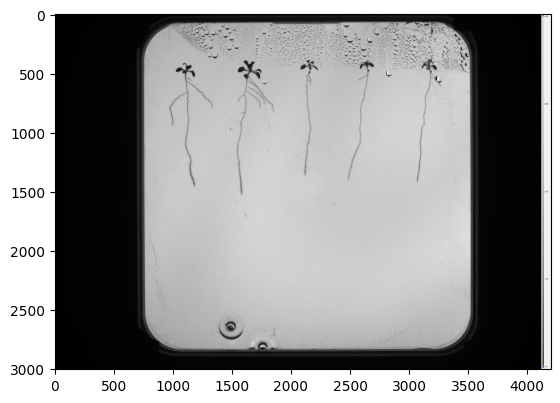

In [5]:
plt.imshow(image, cmap='gray')

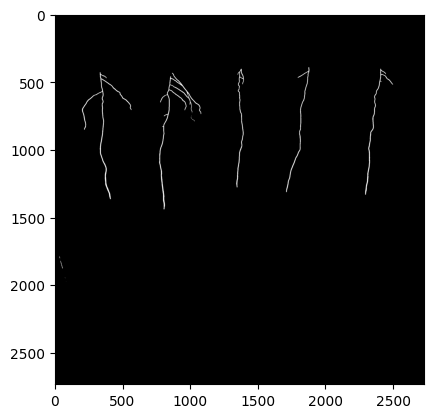

In [6]:
plt.imshow(mask, cmap='gray')

In [7]:
num_lables, lables, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

In [8]:
areas = stats[1:, cv2.CC_STAT_AREA]
lable_ids = np.arange(1, num_lables)

largest_5 = lable_ids[np.argsort(areas)[-5:]]

output = np.zeros_like(mask)

for lbl in largest_5:
    output[lables==lbl] = 255


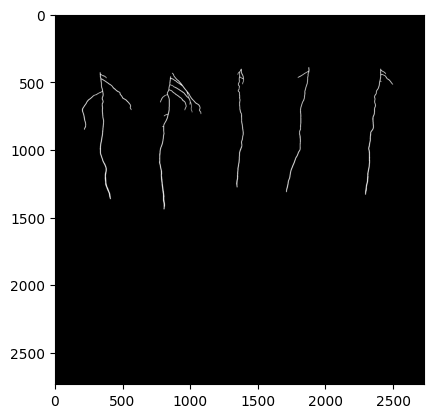

In [9]:
plt.imshow(output, cmap='gray')

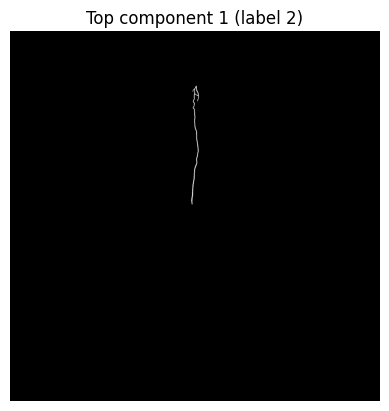

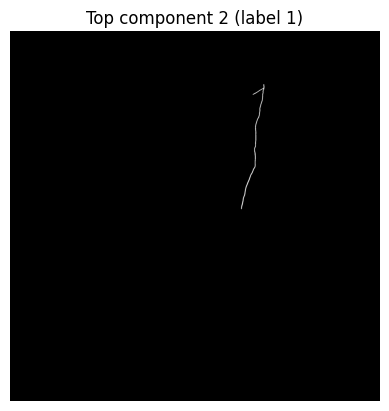

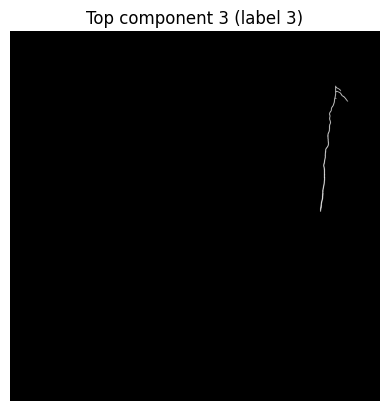

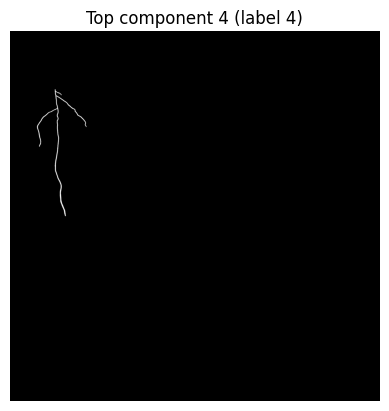

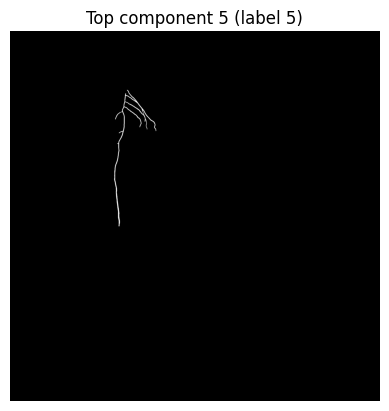

In [10]:
for i, lbl in enumerate(largest_5):
    component = (lables == lbl).astype("uint8") * 255

    plt.figure()
    plt.imshow(component, cmap="gray")
    plt.title(f"Top component {i+1} (label {lbl})")
    plt.axis("off")
    plt.show()


In [11]:
def process_mask_connected_components(mask: np.ndarray, top_n: int = 5, 
                                     min_area: int = 100) -> np.ndarray:
    """
    Keep only the N largest connected components in a binary mask,
    filtering out components smaller than min_area.
    
    Args:
        mask: Binary mask (values 0 or 255)
        top_n: Number of largest components to keep
        min_area: Minimum area (in pixels) for a component to be considered
    
    Returns:
        Filtered mask with only largest components meeting size threshold
        
    Design choice: Filter by size first, then select top N.
    This ensures we don't waste resources on noise/small artifacts.
    Alternative: Could select top N first, but that might include tiny components
    if there aren't enough large ones.
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    
    # Skip label 0 (background)
    areas = stats[1:, cv2.CC_STAT_AREA]
    label_ids = np.arange(1, num_labels)
    
    # Filter by minimum area first
    valid_mask = areas >= min_area
    valid_areas = areas[valid_mask]
    valid_labels = label_ids[valid_mask]
    
    # Handle case where no components meet minimum size
    if len(valid_labels) == 0:
        return np.zeros_like(mask)
    
    # Get indices of largest valid components
    actual_top_n = min(top_n, len(valid_labels))
    largest_n = valid_labels[np.argsort(valid_areas)[-actual_top_n:]]
    
    # Create output mask
    output = np.zeros_like(mask)
    for lbl in largest_n:
        output[labels == lbl] = 255
    
    return output


def process_all_masks(top_n: int = 5, min_area: int = 100, visualize: bool = True):
    """
    Process all masks in directory, keeping only largest connected components
    that meet minimum area threshold.
    
    Args:
        top_n: Number of largest components to keep
        min_area: Minimum area in pixels for components to be considered
        visualize: Whether to show component visualizations
        
    Returns:
        Dictionary mapping image names to filtered masks
    """
    masks = load_all_masks()
    filtered_masks = {}
    
    print(f"Processing {len(masks)} masks (min_area={min_area}, top_n={top_n})...")
    
    for image_name, mask in masks.items():
        # Process connected components
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        
        areas = stats[1:, cv2.CC_STAT_AREA]
        label_ids = np.arange(1, num_labels)
        
        # Filter by minimum area
        valid_mask = areas >= min_area
        valid_areas = areas[valid_mask]
        valid_labels = label_ids[valid_mask]
        
        # Get top N from valid components
        if len(valid_labels) > 0:
            actual_top_n = min(top_n, len(valid_labels))
            largest_n = valid_labels[np.argsort(valid_areas)[-actual_top_n:]]
            
            # Create filtered mask
            filtered_mask = process_mask_connected_components(mask, top_n, min_area)
            filtered_masks[image_name] = filtered_mask
            
            print(f"  {image_name}: Found {num_labels-1} total, "
                  f"{len(valid_labels)} >= {min_area}px, kept top {actual_top_n}")
            
            # Visualize if requested
            if visualize:
                visualize_components(mask, labels, largest_n, image_name)
        else:
            # No components meet minimum size
            filtered_masks[image_name] = np.zeros_like(mask)
            print(f"  {image_name}: No components >= {min_area}px, returning empty mask")
    
    return filtered_masks


# Usage examples
# Keep top 5 components with minimum area of 100 pixels
#filtered_masks = process_all_masks(top_n=5, min_area=100, visualize=True)

# If you want to save the filtered masks
def save_filtered_masks(filtered_masks: Dict[str, np.ndarray], output_dir: Path):
    """
    Save filtered masks to directory.
    
    Args:
        filtered_masks: Dictionary of filtered masks
        output_dir: Directory to save masks to
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for image_name, mask in filtered_masks.items():
        stem = Path(image_name).stem
        output_path = output_dir / f'{stem}_filtered.png'
        cv2.imwrite(str(output_path), mask)
        
    print(f"Saved {len(filtered_masks)} filtered masks to {output_dir}")


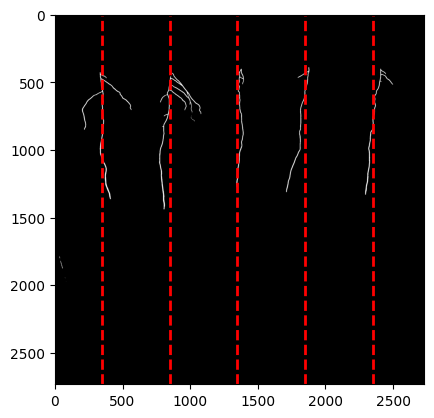

In [12]:
plt.imshow(mask, cmap='gray')

# Draw vertical lines over it
start = 350
end = mask.shape[1]  # width of the mask
step = 500

for x in range(start, end, step):
    plt.axvline(x=x, color='red', linestyle='--', linewidth=2)

plt.show()

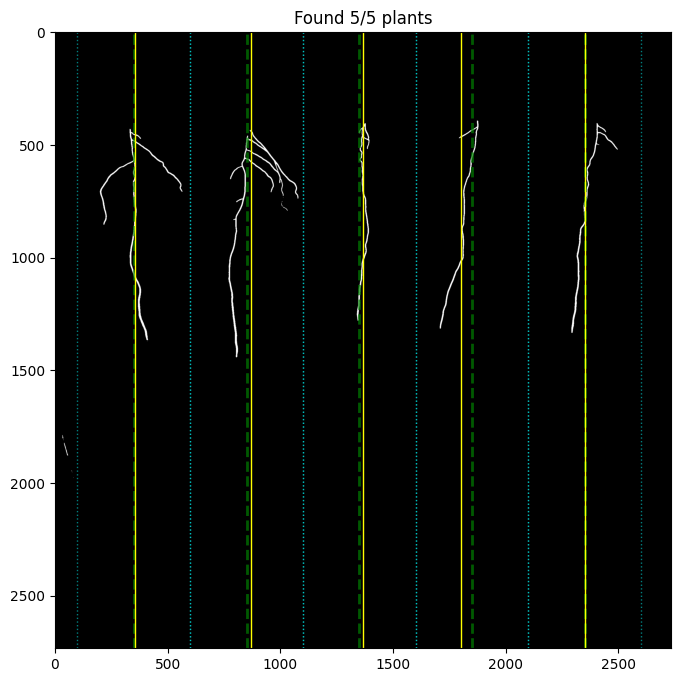

Plant 0: Found at x=355.5 (expected: 350, area: 10861 pixels)
Plant 1: Found at x=869.0 (expected: 850, area: 12685 pixels)
Plant 2: Found at x=1366.8 (expected: 1350, area: 5985 pixels)
Plant 3: Found at x=1802.5 (expected: 1850, area: 6008 pixels)
Plant 4: Found at x=2353.1 (expected: 2350, area: 7051 pixels)


In [13]:
from scipy.ndimage import label

def find_plants_in_rois(mask, expected_positions, roi_width=250):
    """
    Search for plants at expected positions within defined ROIs.
    
    Parameters:
    - mask: binary mask (plant=white, background=black)
    - expected_positions: list of x-coordinates where plants are expected
    - roi_width: half-width of search region around each position (total width = 2*roi_width)
    
    Returns:
    - found_plants: list of dicts with plant info for each expected position
    """
    h, w = mask.shape
    found_plants = []
    
    for i, x_center in enumerate(expected_positions):
        # Define ROI boundaries
        x_min = max(0, x_center - roi_width)
        x_max = min(w, x_center + roi_width)
        
        # Extract ROI
        roi = mask[:, x_min:x_max]
        
        # Find connected components in this ROI only
        labeled_roi, num_features = label(roi)
        
        if num_features == 0:
            # No plant found in this ROI
            found_plants.append({
                'plant_id': i,
                'found': False,
                'x_center': x_center,
                'roi_bounds': (x_min, x_max)
            })
        else:
            # Find the largest component (likely the main plant)
            component_sizes = [(labeled_roi == j).sum() for j in range(1, num_features + 1)]
            largest_component = np.argmax(component_sizes) + 1
            
            # Get component mask in original coordinates
            component_mask = (labeled_roi == largest_component)
            
            # Calculate actual center of the found plant
            y_coords, x_coords = np.where(component_mask)
            actual_x_center = x_coords.mean() + x_min  # shift back to original coordinates
            
            found_plants.append({
                'plant_id': i,
                'found': True,
                'x_center': x_center,
                'actual_x_center': actual_x_center,
                'roi_bounds': (x_min, x_max),
                'area': component_sizes[largest_component - 1],
                'component_mask': component_mask  # in ROI coordinates
            })
    
    return found_plants

# Usage
mask = mask  # binary mask

# Define expected plant positions (your vertical lines)
expected_positions = list(range(350, mask.shape[1], 500))

# Search for plants
plants = find_plants_in_rois(mask, expected_positions, roi_width=250)

# Visualize results
plt.figure(figsize=(12, 8))
plt.imshow(mask, cmap='gray')

for plant in plants:
    x_center = plant['x_center']
    x_min, x_max = plant['roi_bounds']
    
    if plant['found']:
        # Draw green line for found plants
        plt.axvline(x=x_center, color='green', linestyle='--', linewidth=2, alpha=0.7)
        # Draw ROI bounds
        plt.axvline(x=x_min, color='cyan', linestyle=':', linewidth=1, alpha=0.5)
        plt.axvline(x=x_max, color='cyan', linestyle=':', linewidth=1, alpha=0.5)
        # Mark actual plant center
        plt.axvline(x=plant['actual_x_center'], color='yellow', linestyle='-', linewidth=1)
    else:
        # Draw red line for missing plants
        plt.axvline(x=x_center, color='red', linestyle='--', linewidth=2, alpha=0.7)
        plt.axvline(x=x_min, color='red', linestyle=':', linewidth=1, alpha=0.3)
        plt.axvline(x=x_max, color='red', linestyle=':', linewidth=1, alpha=0.3)

plt.title(f'Found {sum(p["found"] for p in plants)}/{len(plants)} plants')
plt.show()

# Print results
for plant in plants:
    if plant['found']:
        print(f"Plant {plant['plant_id']}: Found at x={plant['actual_x_center']:.1f} "
              f"(expected: {plant['x_center']}, area: {plant['area']} pixels)")
    else:
        print(f"Plant {plant['plant_id']}: NOT FOUND at expected x={plant['x_center']}")


=== DETECTION SUMMARY ===

test_image_01.png:
  Expected: 5, Found: 4, Missing: 1
  Detection rate: 80.0%
  Average area: 21144 pixels

test_image_02.png:
  Expected: 5, Found: 5, Missing: 0
  Detection rate: 100.0%
  Average area: 8518 pixels

test_image_03.png:
  Expected: 5, Found: 5, Missing: 0
  Detection rate: 100.0%
  Average area: 400 pixels

test_image_04.png:
  Expected: 5, Found: 5, Missing: 0
  Detection rate: 100.0%
  Average area: 4406 pixels

test_image_05.png:
  Expected: 5, Found: 5, Missing: 0
  Detection rate: 100.0%
  Average area: 313 pixels

test_image_06.png:
  Expected: 5, Found: 5, Missing: 0
  Detection rate: 100.0%
  Average area: 848 pixels

test_image_07.png:
  Expected: 5, Found: 5, Missing: 0
  Detection rate: 100.0%
  Average area: 9919 pixels

test_image_08.png:
  Expected: 5, Found: 4, Missing: 1
  Detection rate: 80.0%
  Average area: 2338 pixels

test_image_09.png:
  Expected: 5, Found: 5, Missing: 0
  Detection rate: 100.0%
  Average area: 6962 pix

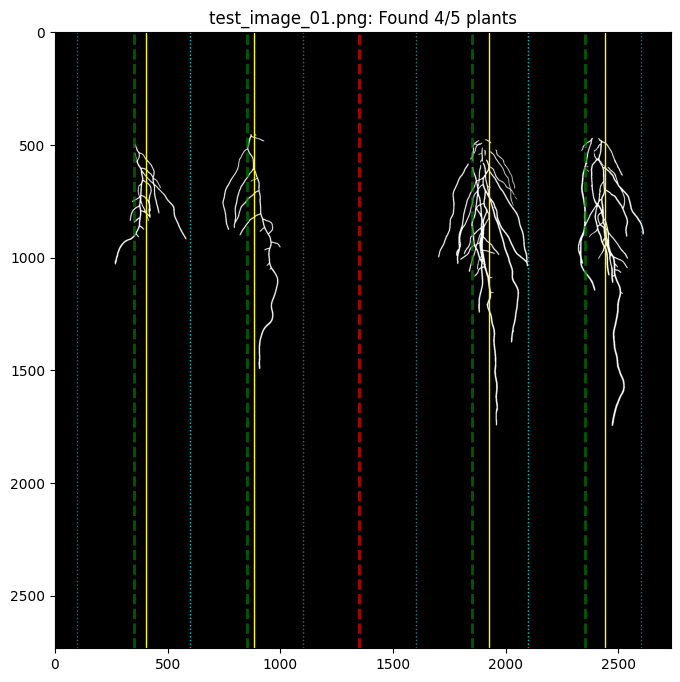

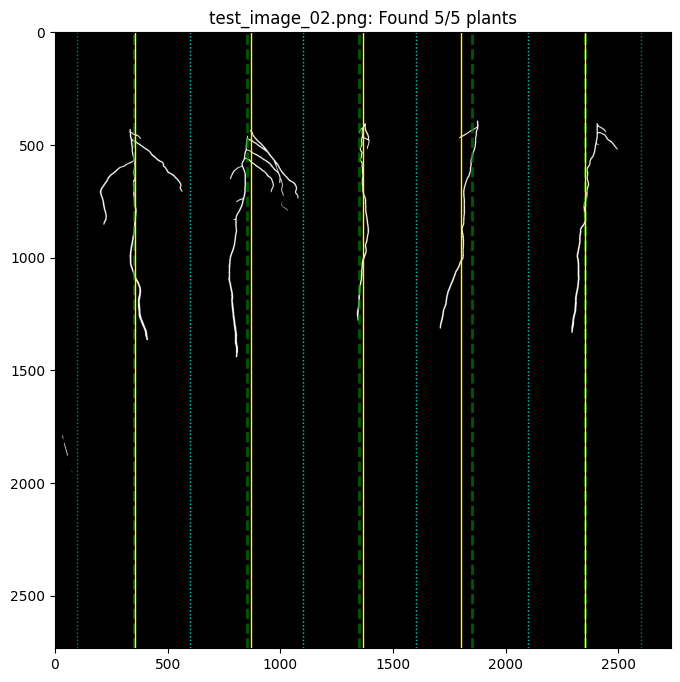

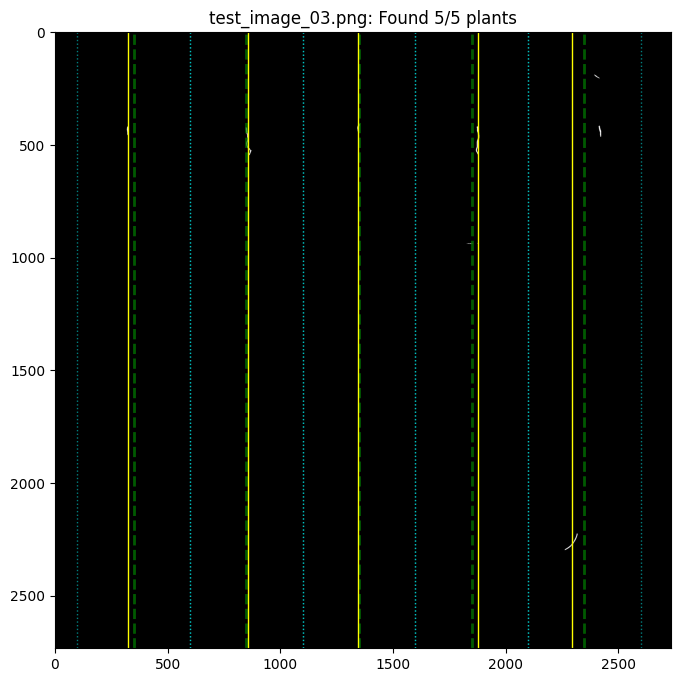

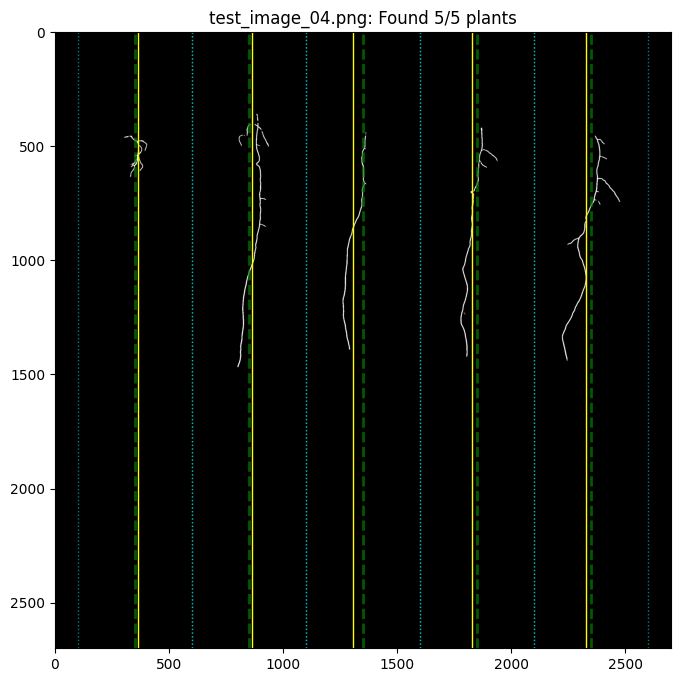

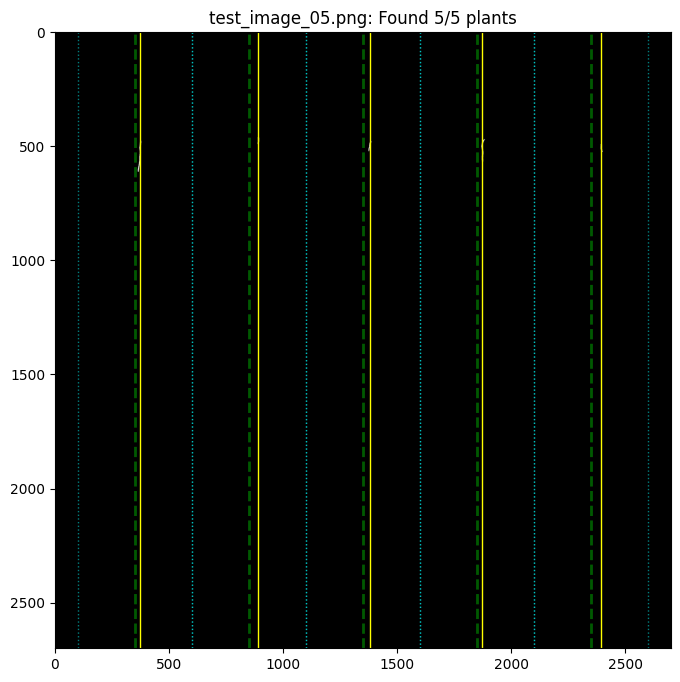

In [14]:
from typing import Dict, List, Tuple
import numpy as np
from scipy.ndimage import label
import matplotlib.pyplot as plt

def find_plants_in_rois(mask, expected_positions, roi_width=250):
    """
    Search for plants at expected positions within defined ROIs.
    
    Parameters:
    - mask: binary mask (plant=white, background=black)
    - expected_positions: list of x-coordinates where plants are expected
    - roi_width: half-width of search region around each position
    
    Returns:
    - found_plants: list of dicts with plant info for each expected position
    """
    h, w = mask.shape
    found_plants = []
    
    for i, x_center in enumerate(expected_positions):
        x_min = max(0, x_center - roi_width)
        x_max = min(w, x_center + roi_width)
        
        roi = mask[:, x_min:x_max]
        labeled_roi, num_features = label(roi)
        
        if num_features == 0:
            found_plants.append({
                'plant_id': i,
                'found': False,
                'x_center': x_center,
                'roi_bounds': (x_min, x_max)
            })
        else:
            component_sizes = [(labeled_roi == j).sum() for j in range(1, num_features + 1)]
            largest_component = np.argmax(component_sizes) + 1
            
            component_mask = (labeled_roi == largest_component)
            y_coords, x_coords = np.where(component_mask)
            actual_x_center = x_coords.mean() + x_min
            
            found_plants.append({
                'plant_id': i,
                'found': True,
                'x_center': x_center,
                'actual_x_center': actual_x_center,
                'roi_bounds': (x_min, x_max),
                'area': component_sizes[largest_component - 1],
                'component_mask': component_mask
            })
    
    return found_plants


def process_all_masks(masks: Dict[str, np.ndarray], 
                      start: int = 350, 
                      step: int = 500, 
                      roi_width: int = 250) -> Dict[str, List[dict]]:
    """
    Process all masks to detect plants at expected positions.
    
    Parameters:
    - masks: Dictionary of {image_name: mask_array}
    - start: Starting x-position for first expected plant
    - step: Distance between expected plant positions
    - roi_width: Half-width of search region around each position
    
    Returns:
    - Dictionary of {image_name: list_of_plant_detections}
    """
    results = {}
    
    for image_name, mask in masks.items():
        # Calculate expected positions for this mask
        expected_positions = list(range(start, mask.shape[1], step))
        
        # Find plants in ROIs
        plants = find_plants_in_rois(mask, expected_positions, roi_width)
        
        results[image_name] = plants
    
    return results


def get_detection_summary(results: Dict[str, List[dict]]) -> Dict[str, dict]:
    """
    Get summary statistics for all processed images.
    
    Parameters:
    - results: Output from process_all_masks()
    
    Returns:
    - Dictionary with summary info for each image
    """
    summary = {}
    
    for image_name, plants in results.items():
        total_expected = len(plants)
        total_found = sum(p['found'] for p in plants)
        
        found_areas = [p['area'] for p in plants if p['found']]
        
        summary[image_name] = {
            'expected': total_expected,
            'found': total_found,
            'missing': total_expected - total_found,
            'detection_rate': total_found / total_expected if total_expected > 0 else 0,
            'avg_area': np.mean(found_areas) if found_areas else 0,
            'total_area': sum(found_areas) if found_areas else 0
        }
    
    return summary


def visualize_detections(image_name: str, 
                        mask: np.ndarray, 
                        plants: List[dict],
                        save_path: str = None):
    """
    Visualize detection results for a single image.
    
    Parameters:
    - image_name: Name of the image
    - mask: Binary mask
    - plants: Detection results from find_plants_in_rois()
    - save_path: Optional path to save figure
    """
    plt.figure(figsize=(12, 8))
    plt.imshow(mask, cmap='gray')
    
    for plant in plants:
        x_center = plant['x_center']
        x_min, x_max = plant['roi_bounds']
        
        if plant['found']:
            plt.axvline(x=x_center, color='green', linestyle='--', linewidth=2, alpha=0.7)
            plt.axvline(x=x_min, color='cyan', linestyle=':', linewidth=1, alpha=0.5)
            plt.axvline(x=x_max, color='cyan', linestyle=':', linewidth=1, alpha=0.5)
            plt.axvline(x=plant['actual_x_center'], color='yellow', linestyle='-', linewidth=1)
        else:
            plt.axvline(x=x_center, color='red', linestyle='--', linewidth=2, alpha=0.7)
            plt.axvline(x=x_min, color='red', linestyle=':', linewidth=1, alpha=0.3)
            plt.axvline(x=x_max, color='red', linestyle=':', linewidth=1, alpha=0.3)
    
    found_count = sum(p['found'] for p in plants)
    plt.title(f'{image_name}: Found {found_count}/{len(plants)} plants')
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def visualize_all_detections(masks: Dict[str, np.ndarray], 
                             results: Dict[str, List[dict]],
                             save_dir: str = None,
                             max_display: int = None):
    """
    Visualize detection results for all images.
    
    Parameters:
    - masks: Dictionary of masks
    - results: Detection results from process_all_masks()
    - save_dir: Optional directory to save figures
    - max_display: Maximum number of images to display (None = all)
    """
    from pathlib import Path
    
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
    image_names = list(masks.keys())
    if max_display:
        image_names = image_names[:max_display]
    
    for image_name in image_names:
        mask = masks[image_name]
        plants = results[image_name]
        
        save_path = save_dir / f'{Path(image_name).stem}_detections.png' if save_dir else None
        visualize_detections(image_name, mask, plants, save_path)


# Usage example:
if __name__ == "__main__":
    # Load all masks
    masks = load_all_masks()
    
    # Process all masks
    results = process_all_masks(
        masks,
        start=350,
        step=500,
        roi_width=250
    )
    
    # Get summary
    summary = get_detection_summary(results)
    
    # Print summary
    print("\n=== DETECTION SUMMARY ===")
    for image_name, stats in summary.items():
        print(f"\n{image_name}:")
        print(f"  Expected: {stats['expected']}, Found: {stats['found']}, Missing: {stats['missing']}")
        print(f"  Detection rate: {stats['detection_rate']:.1%}")
        print(f"  Average area: {stats['avg_area']:.0f} pixels")
    
    # Visualize all (or first N)
    visualize_all_detections(masks, results, save_dir='detection_results', max_display=5)
    
    # Access results for specific image
    specific_image = 'image1.png'
    if specific_image in results:
        plants = results[specific_image]
        for plant in plants:
            if plant['found']:
                print(f"Plant {plant['plant_id']}: x={plant['actual_x_center']:.1f}, area={plant['area']}")

STEP 1: Processing images and segmenting plants/roots

Processing 19 images...
Parameters: start=350, step=500, num_plants=5, roi_width=250
Filtering: top_n=5, min_area=100
Root segmentation: min_root_area=50


test_image_01.png:
  Found: 4/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: NOT FOUND
    Plant 3: FOUND, 8 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 11
Saved visualization to segmentation_output_strict/visualizations/test_image_01_segmentation.png


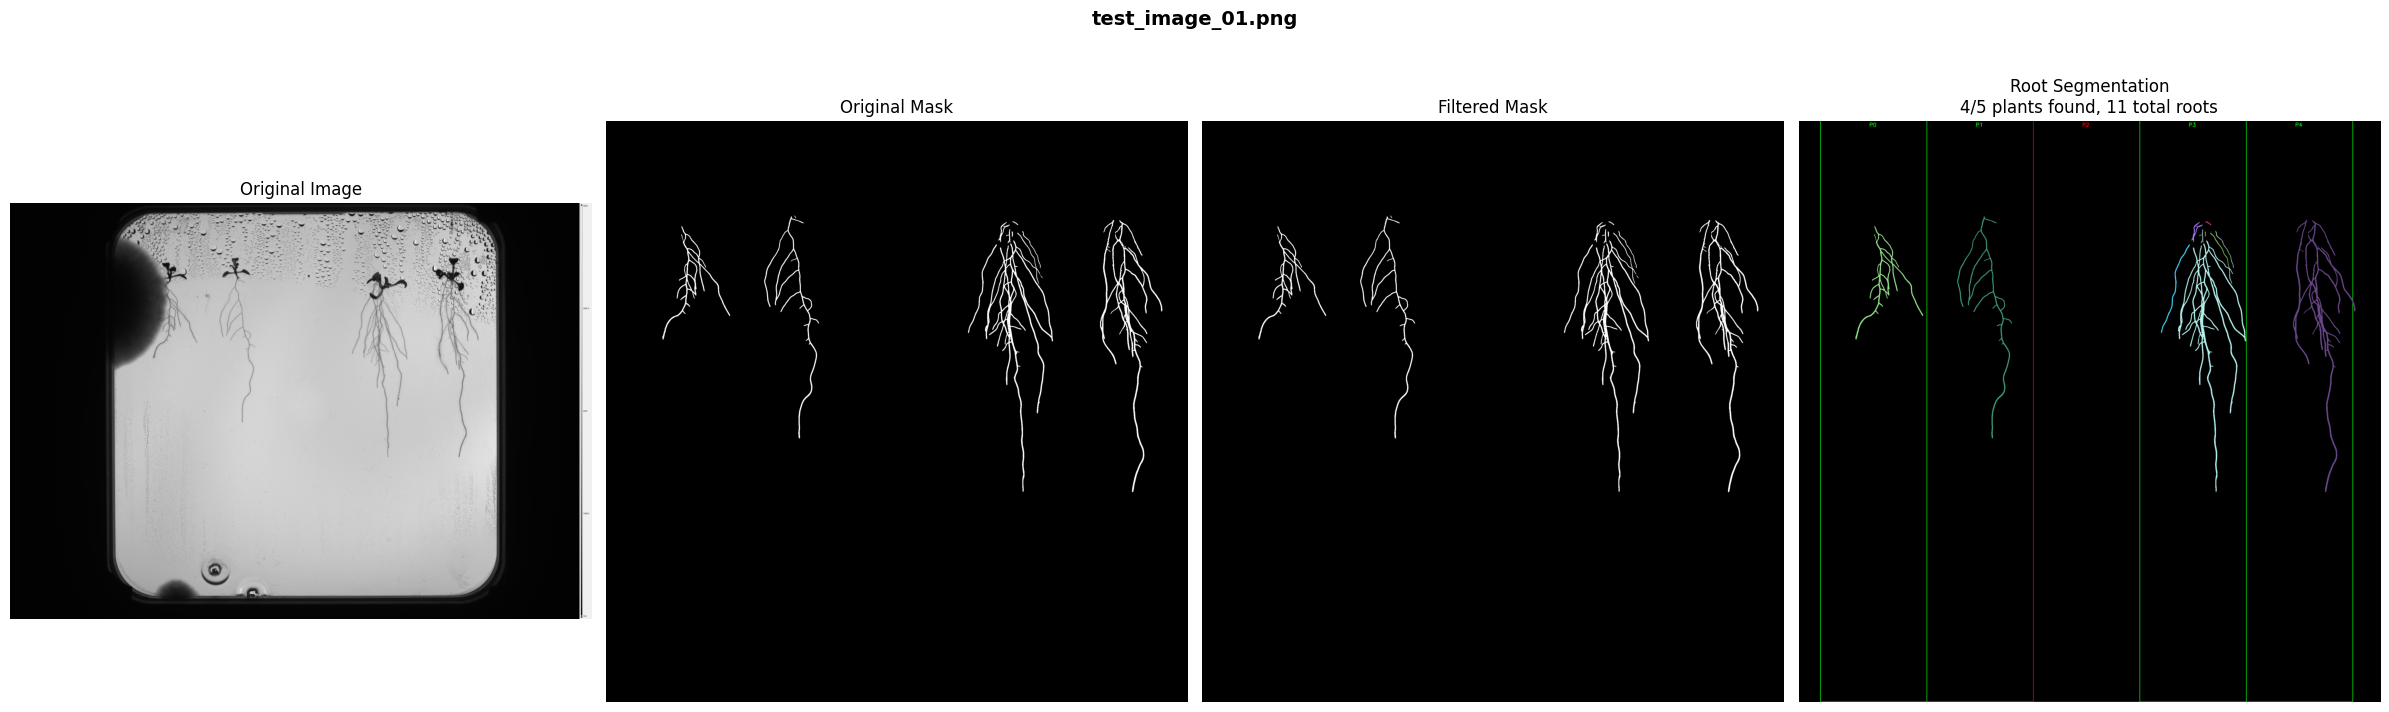


test_image_02.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 2 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 6
Saved visualization to segmentation_output_strict/visualizations/test_image_02_segmentation.png


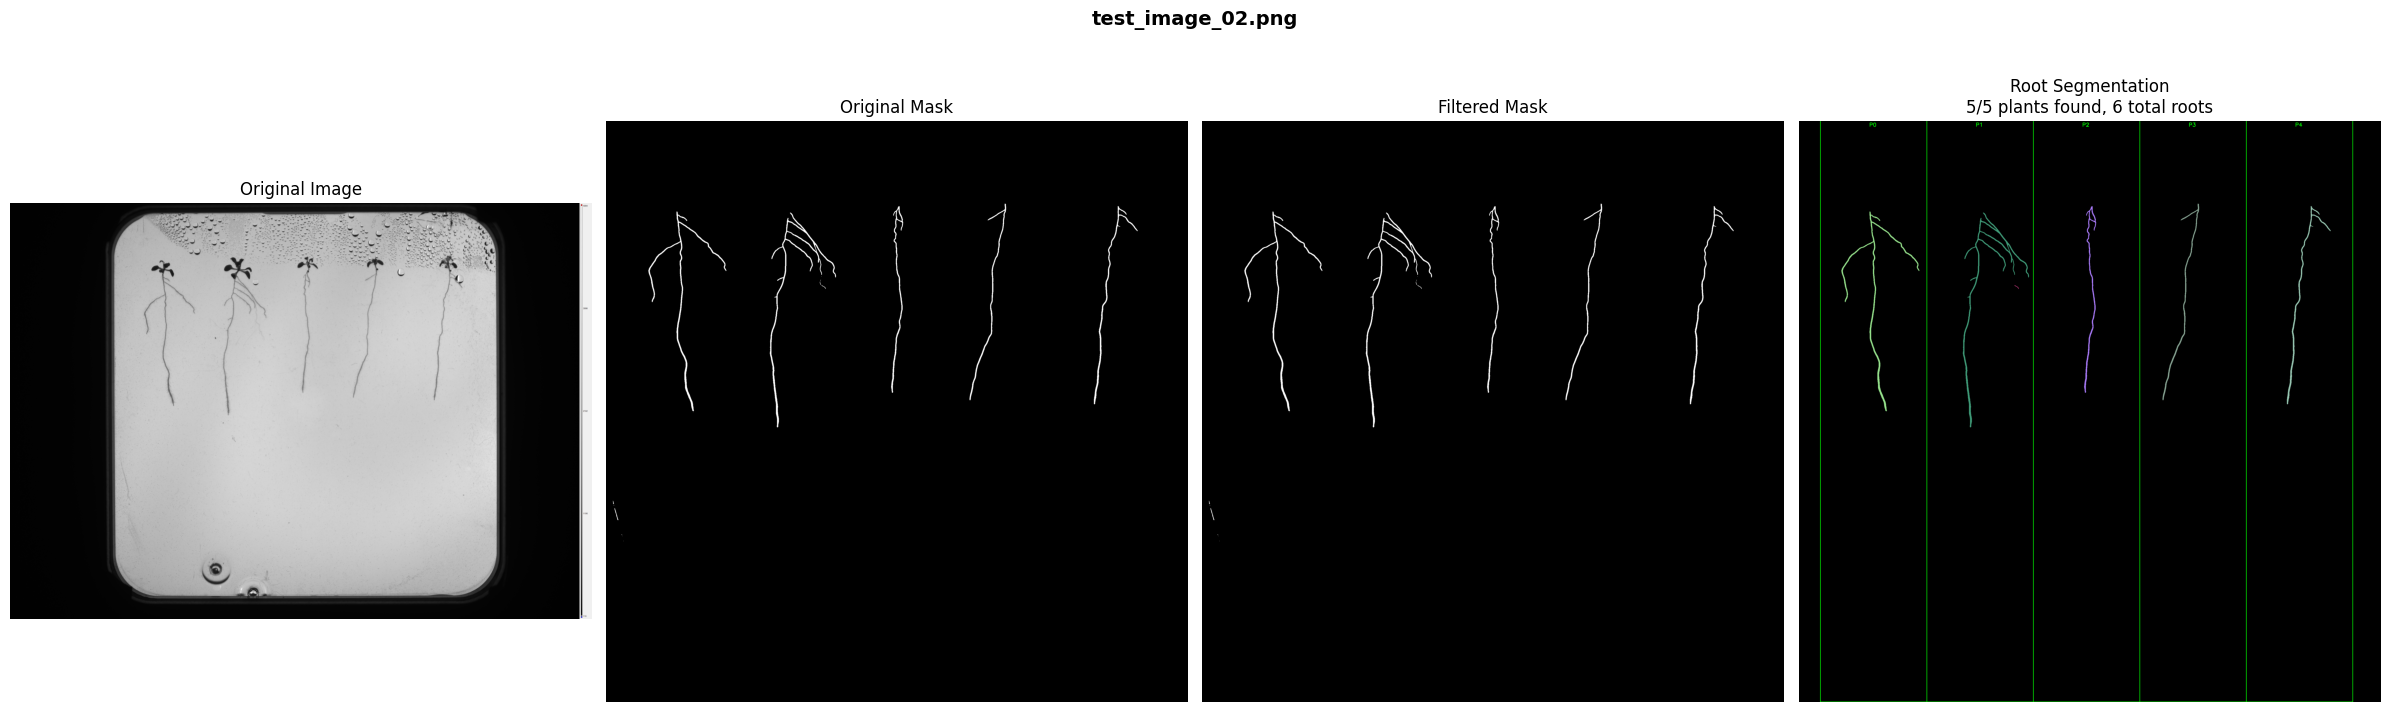


test_image_03.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 3 roots
  Total roots across all plants: 7
Saved visualization to segmentation_output_strict/visualizations/test_image_03_segmentation.png


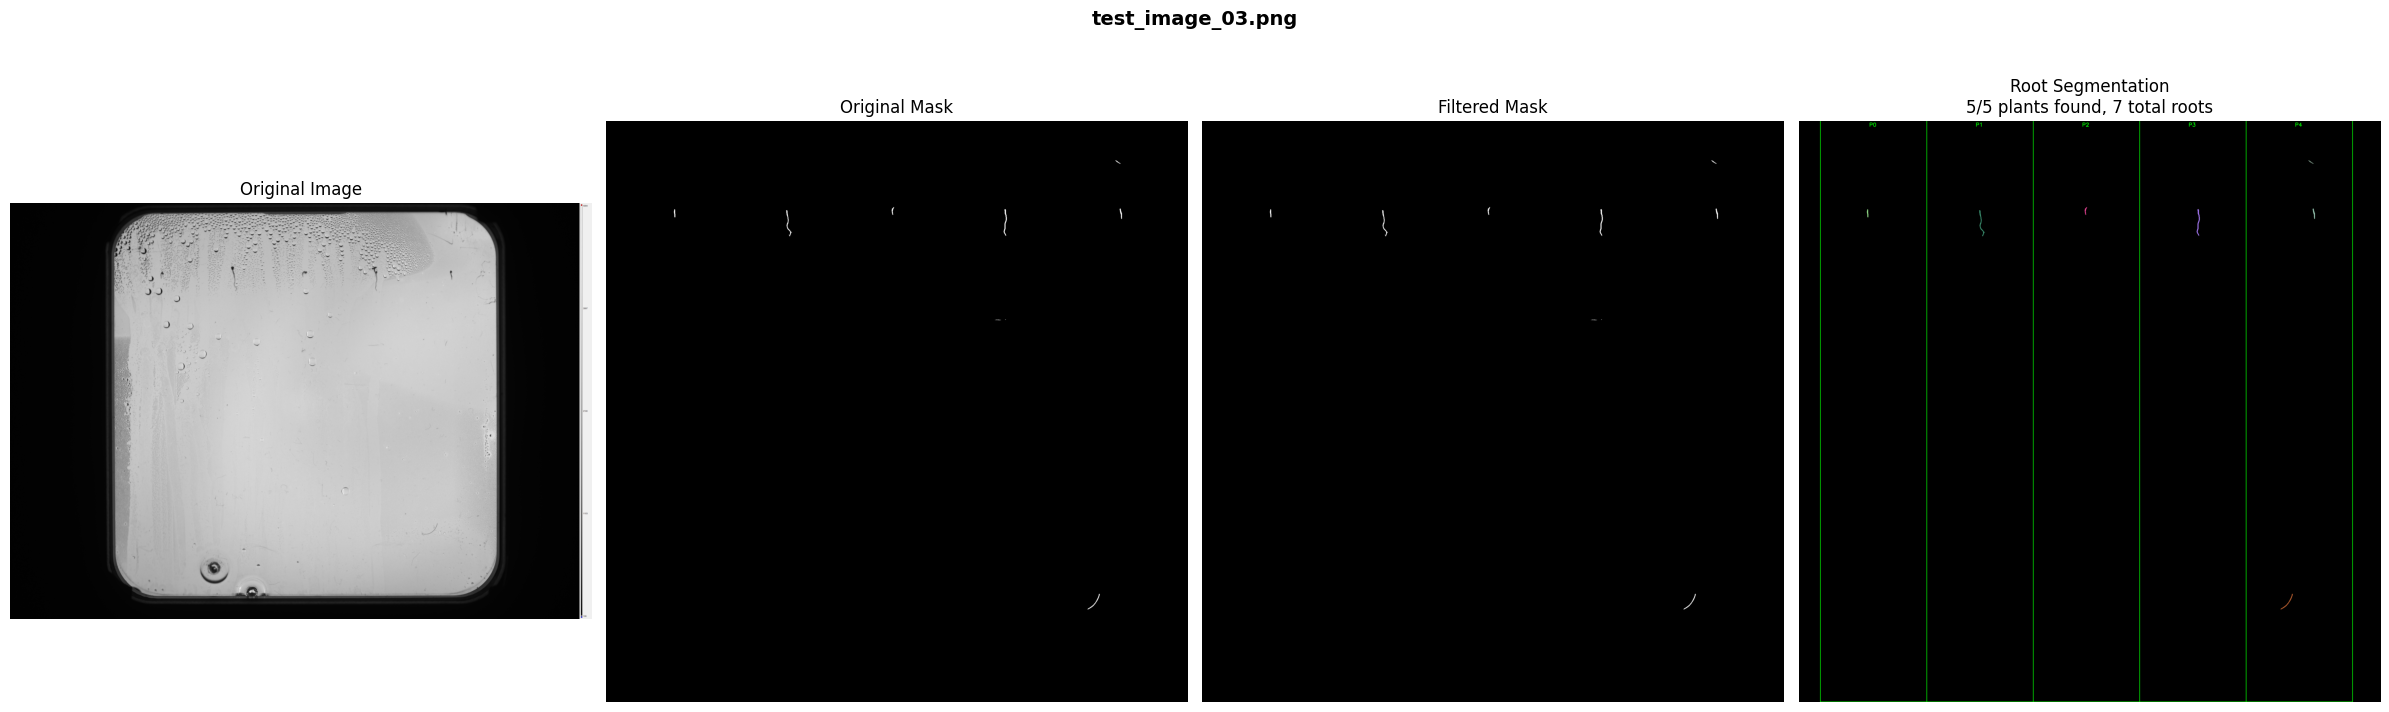


test_image_04.png:
  Found: 5/5 plants
    Plant 0: FOUND, 2 roots
    Plant 1: FOUND, 5 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 2 roots
  Total roots across all plants: 11
Saved visualization to segmentation_output_strict/visualizations/test_image_04_segmentation.png


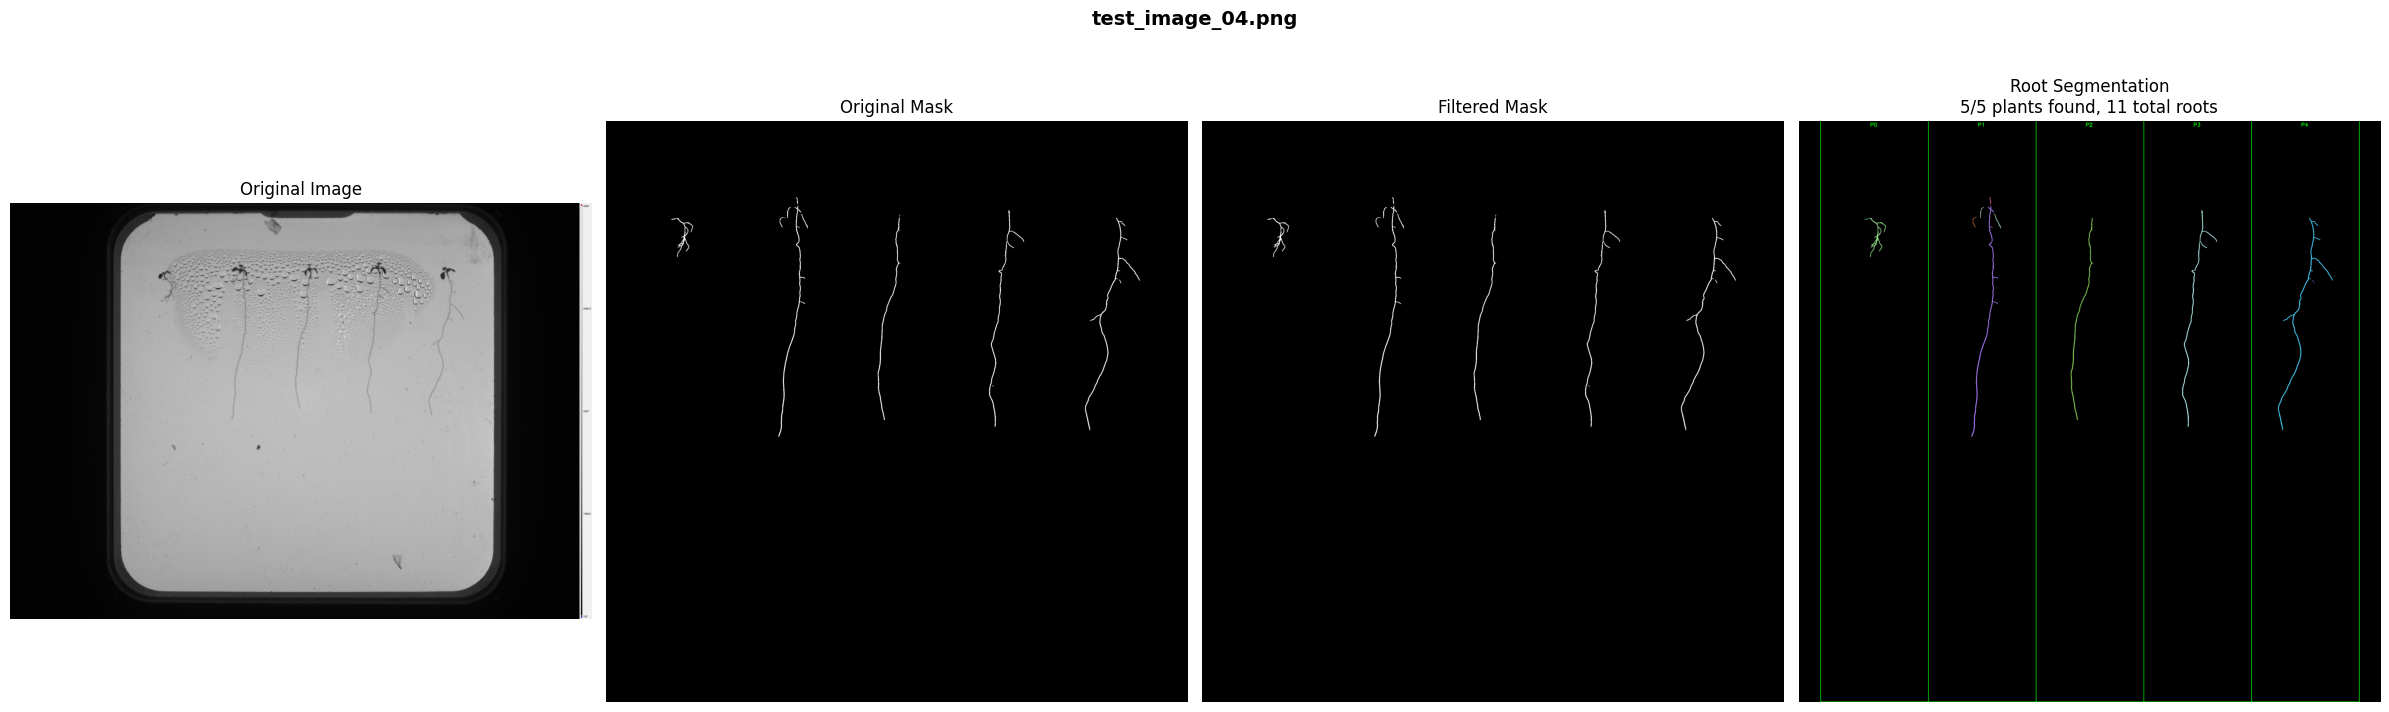


test_image_05.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_05_segmentation.png


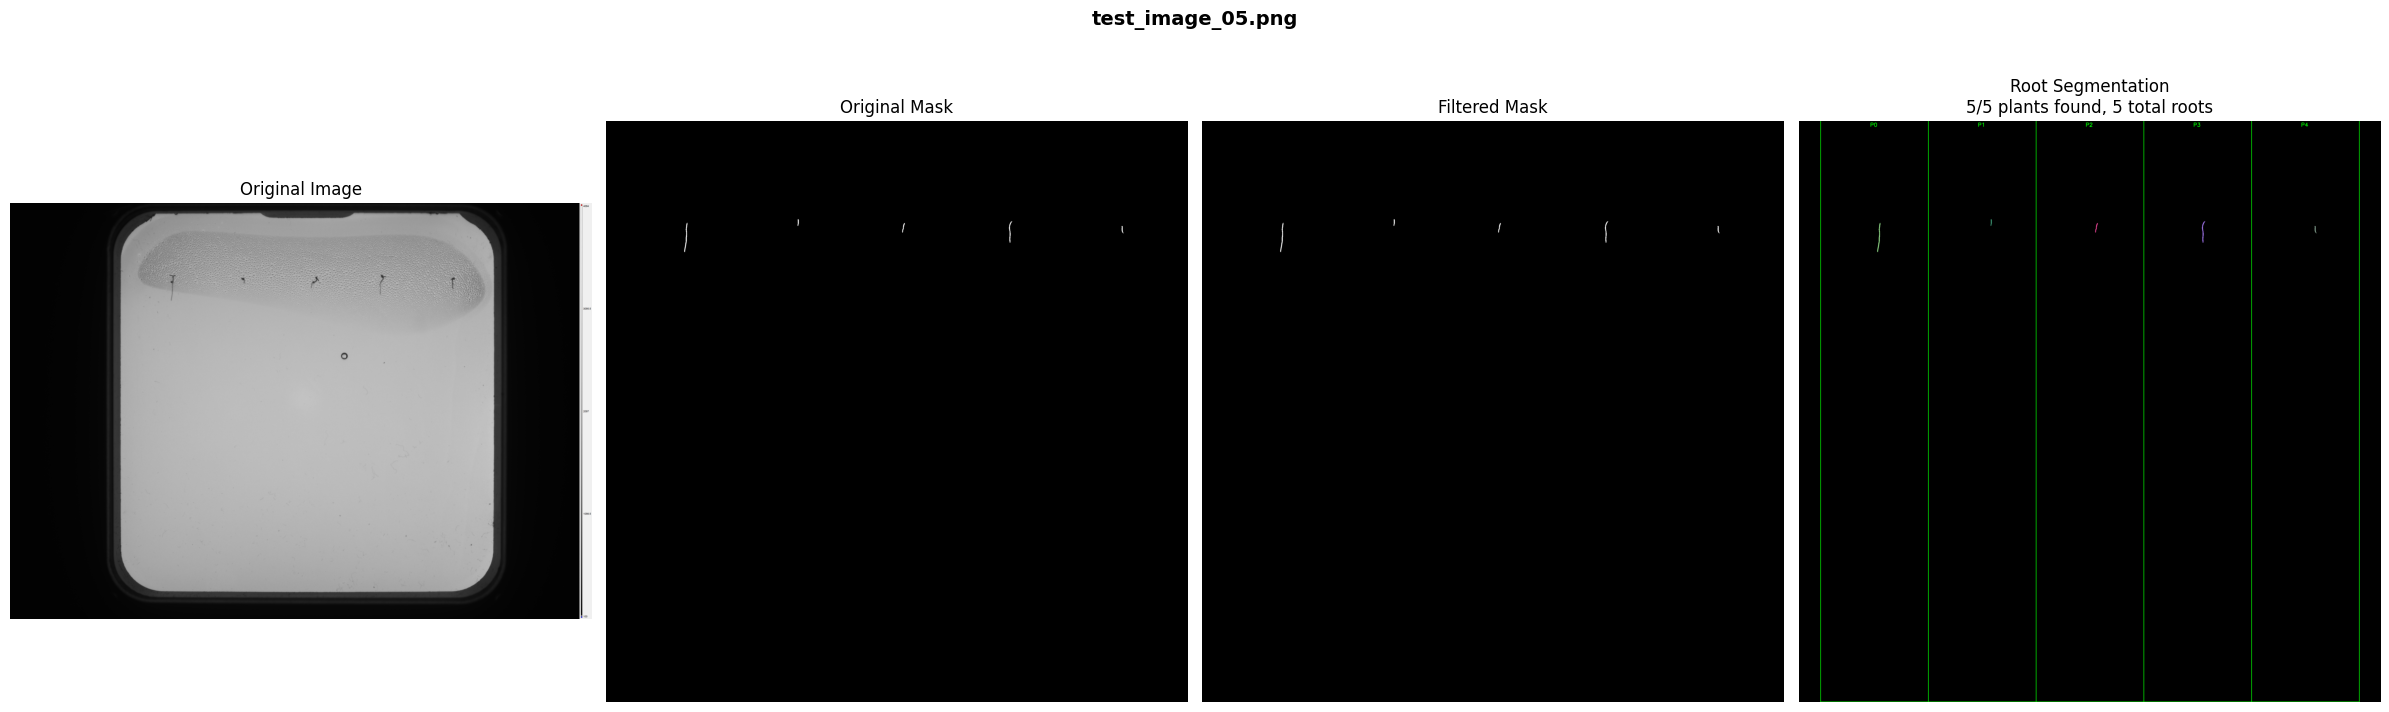


test_image_06.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_06_segmentation.png


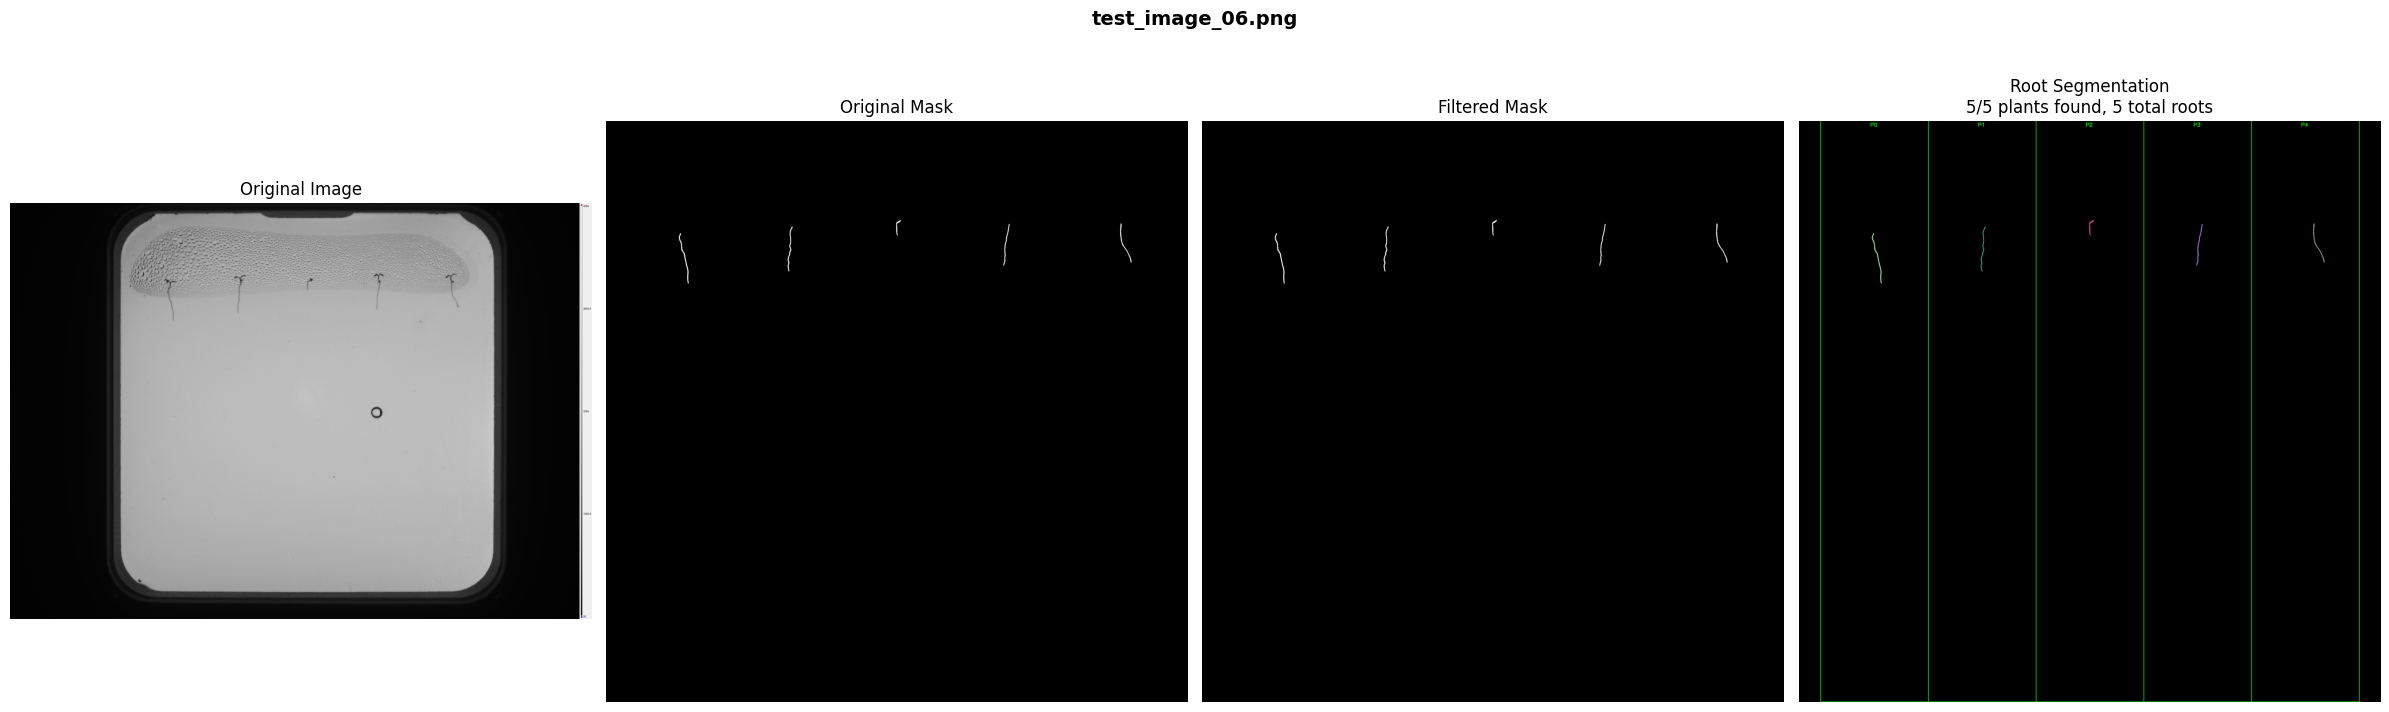


test_image_07.png:
  Found: 5/5 plants
    Plant 0: FOUND, 3 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 4 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 10
Saved visualization to segmentation_output_strict/visualizations/test_image_07_segmentation.png


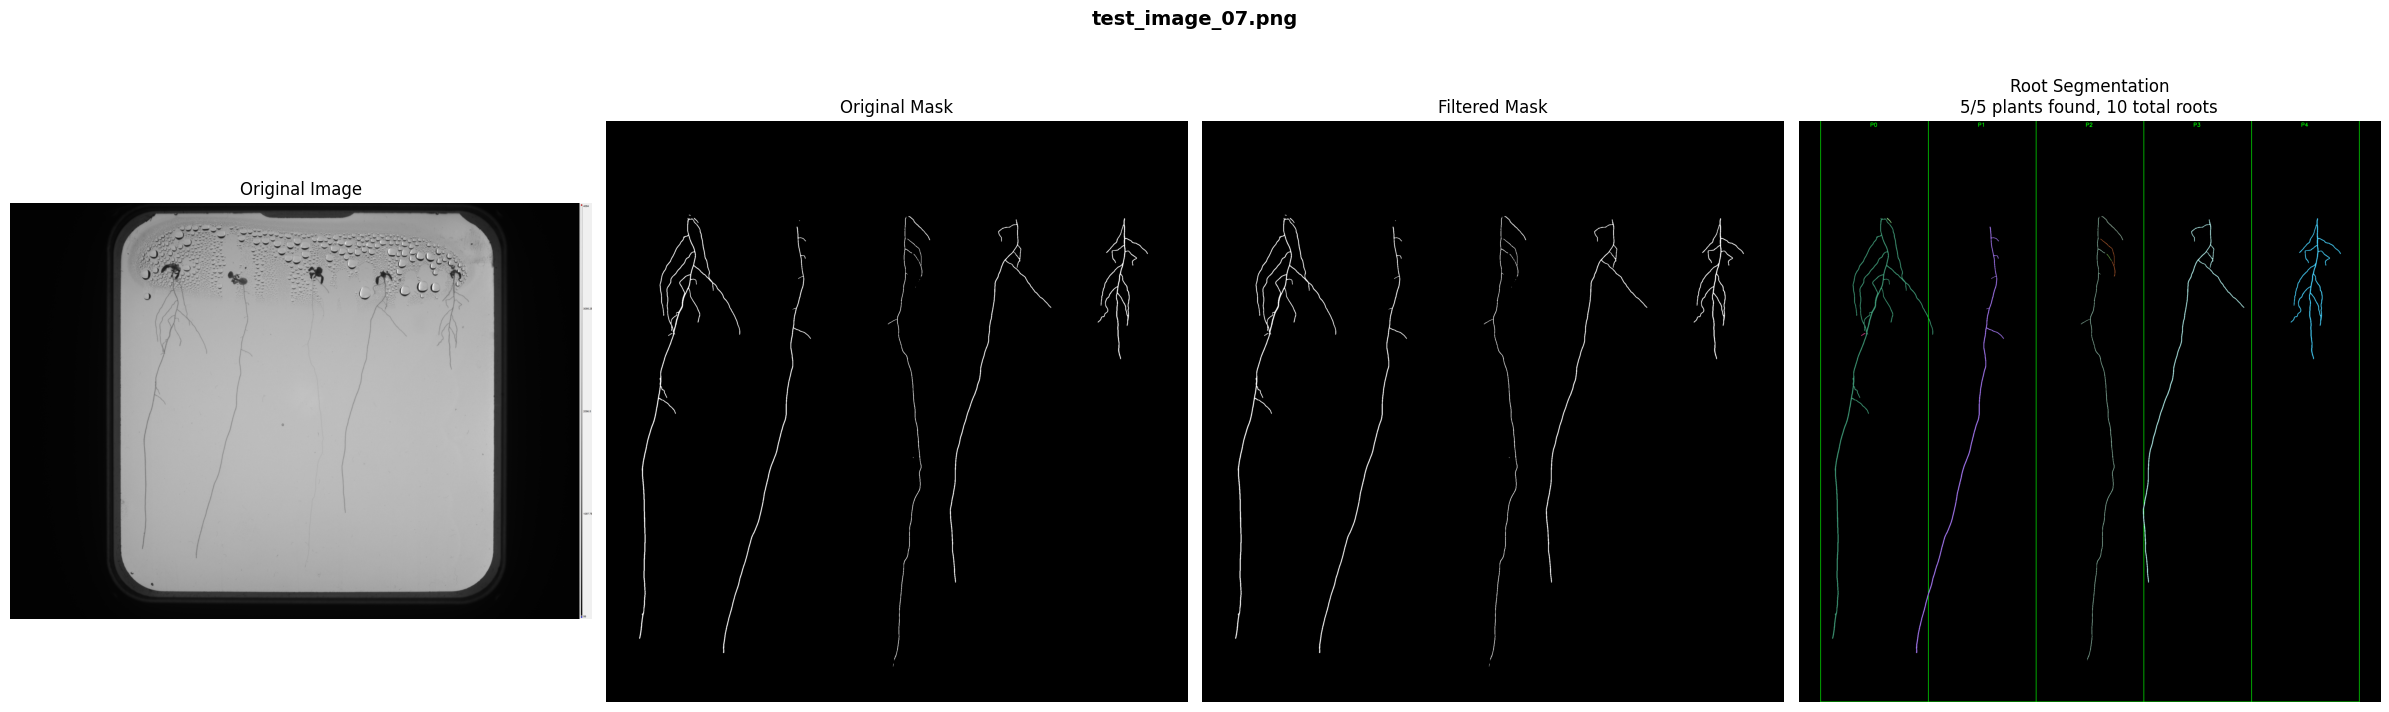


test_image_08.png:
  Found: 4/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: NOT FOUND
    Plant 3: FOUND, 2 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_08_segmentation.png


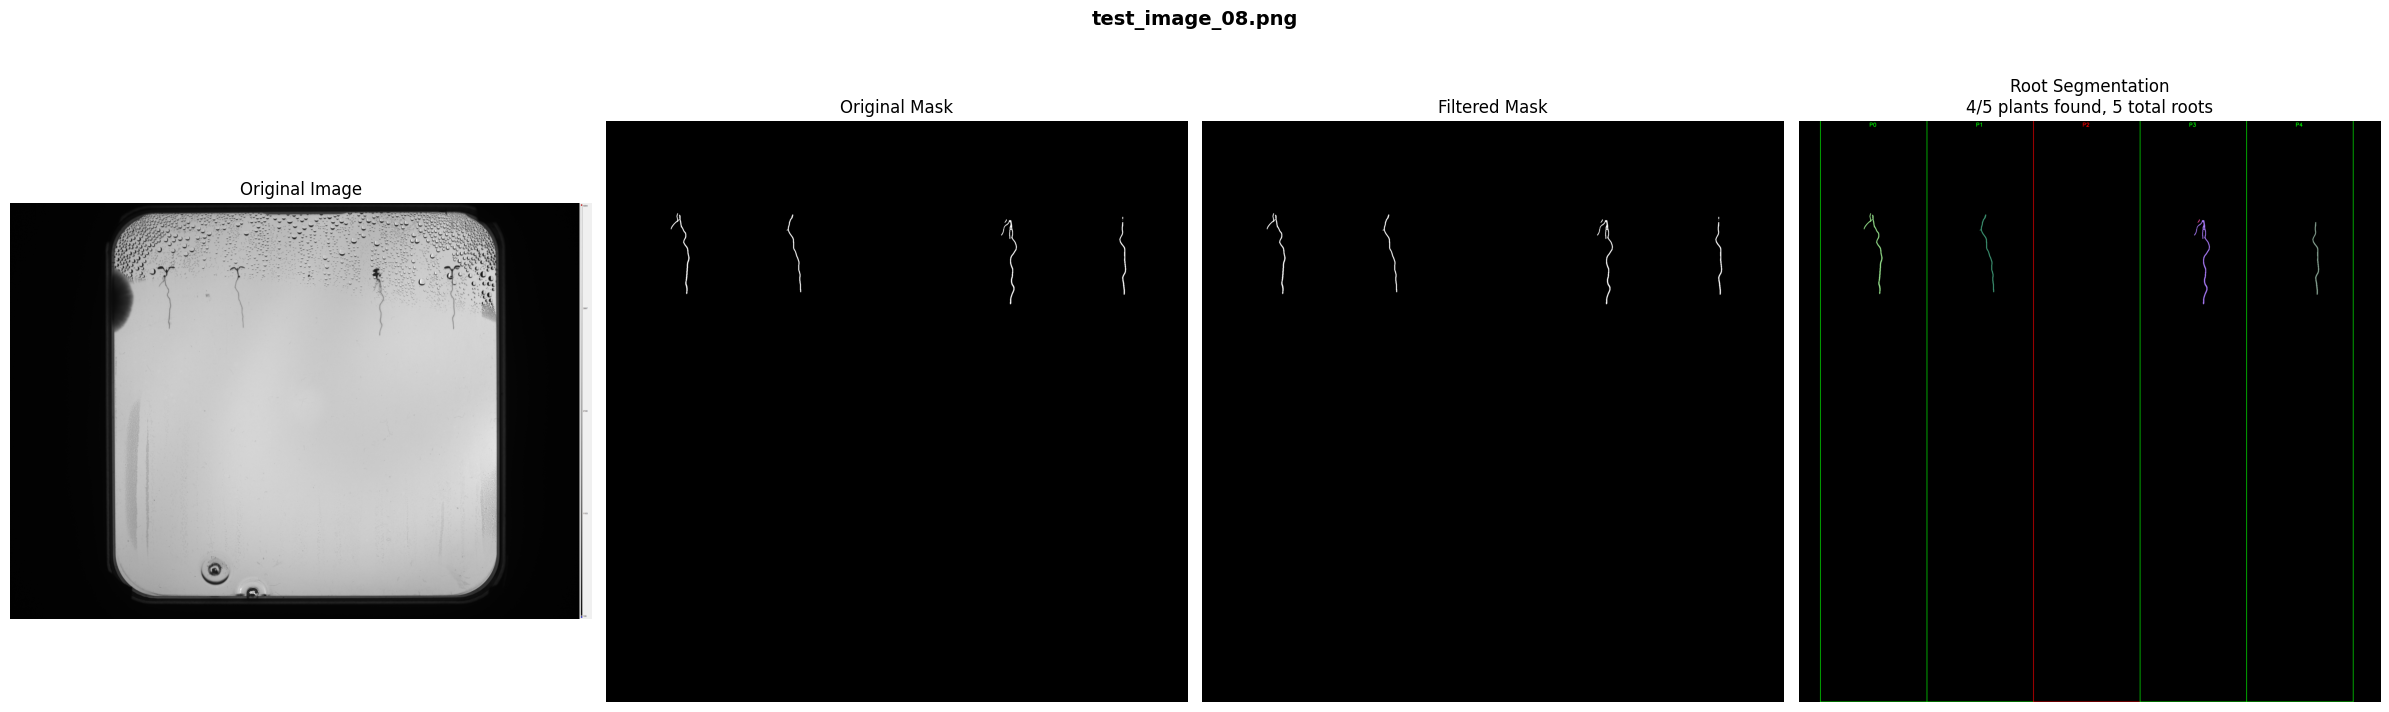


test_image_09.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 3 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 7
Saved visualization to segmentation_output_strict/visualizations/test_image_09_segmentation.png


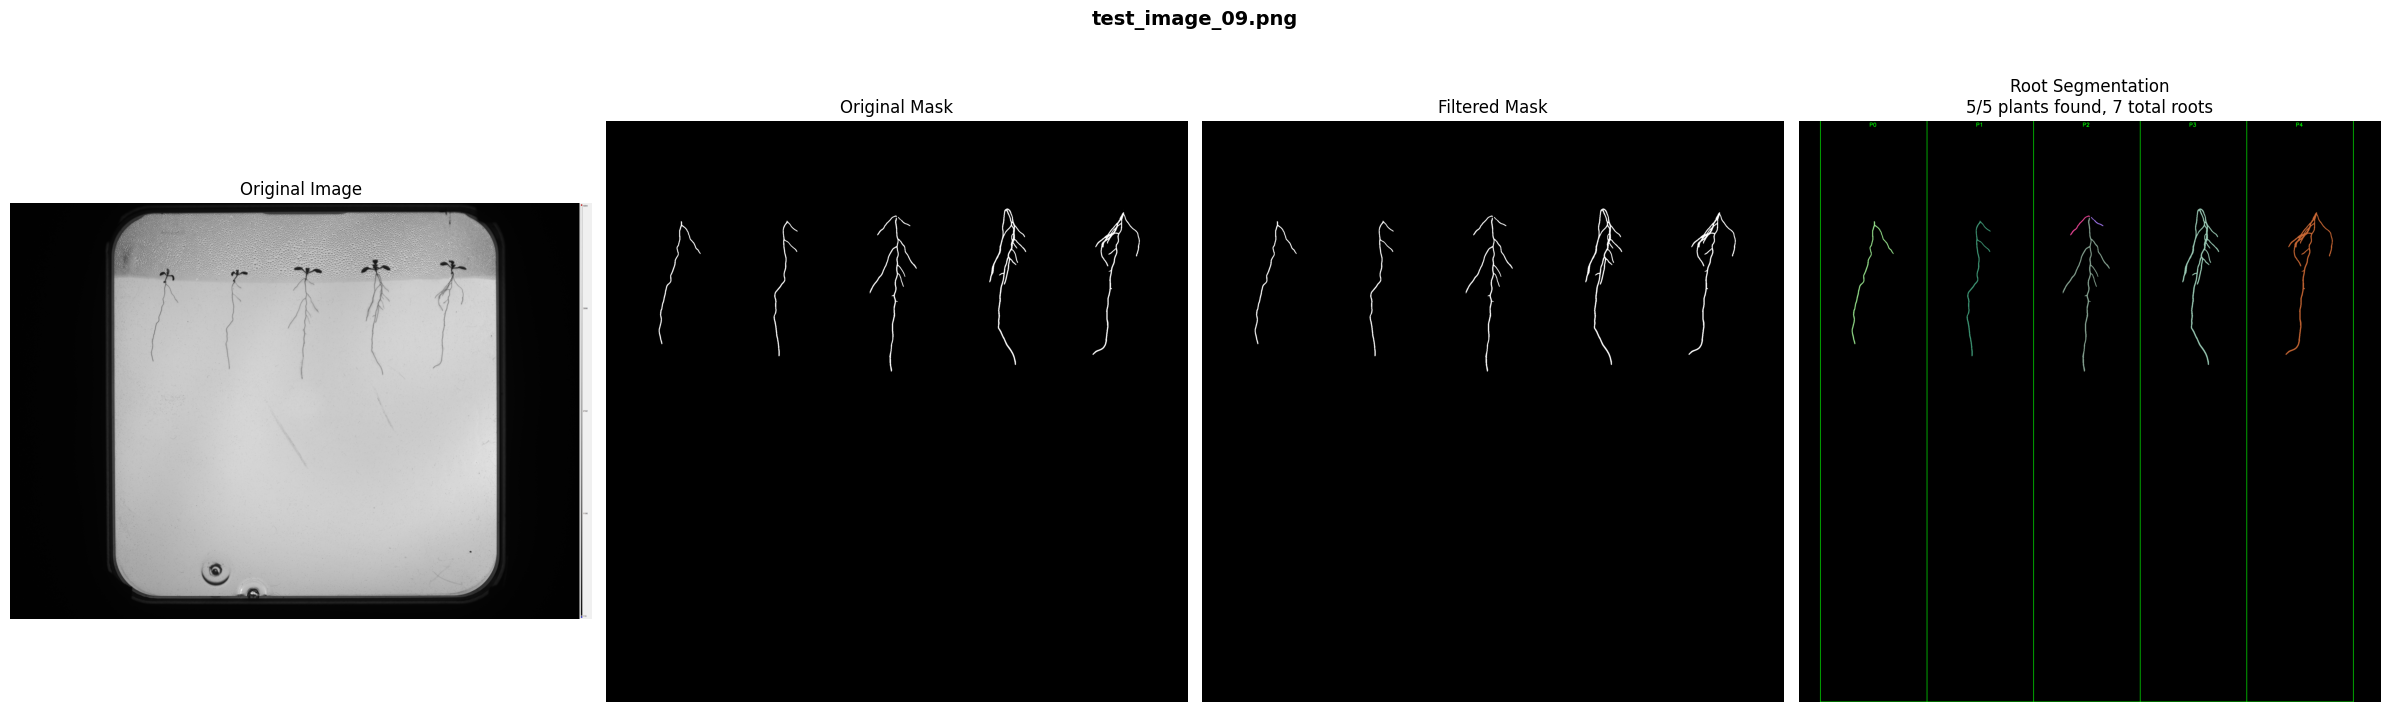


test_image_10.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_10_segmentation.png


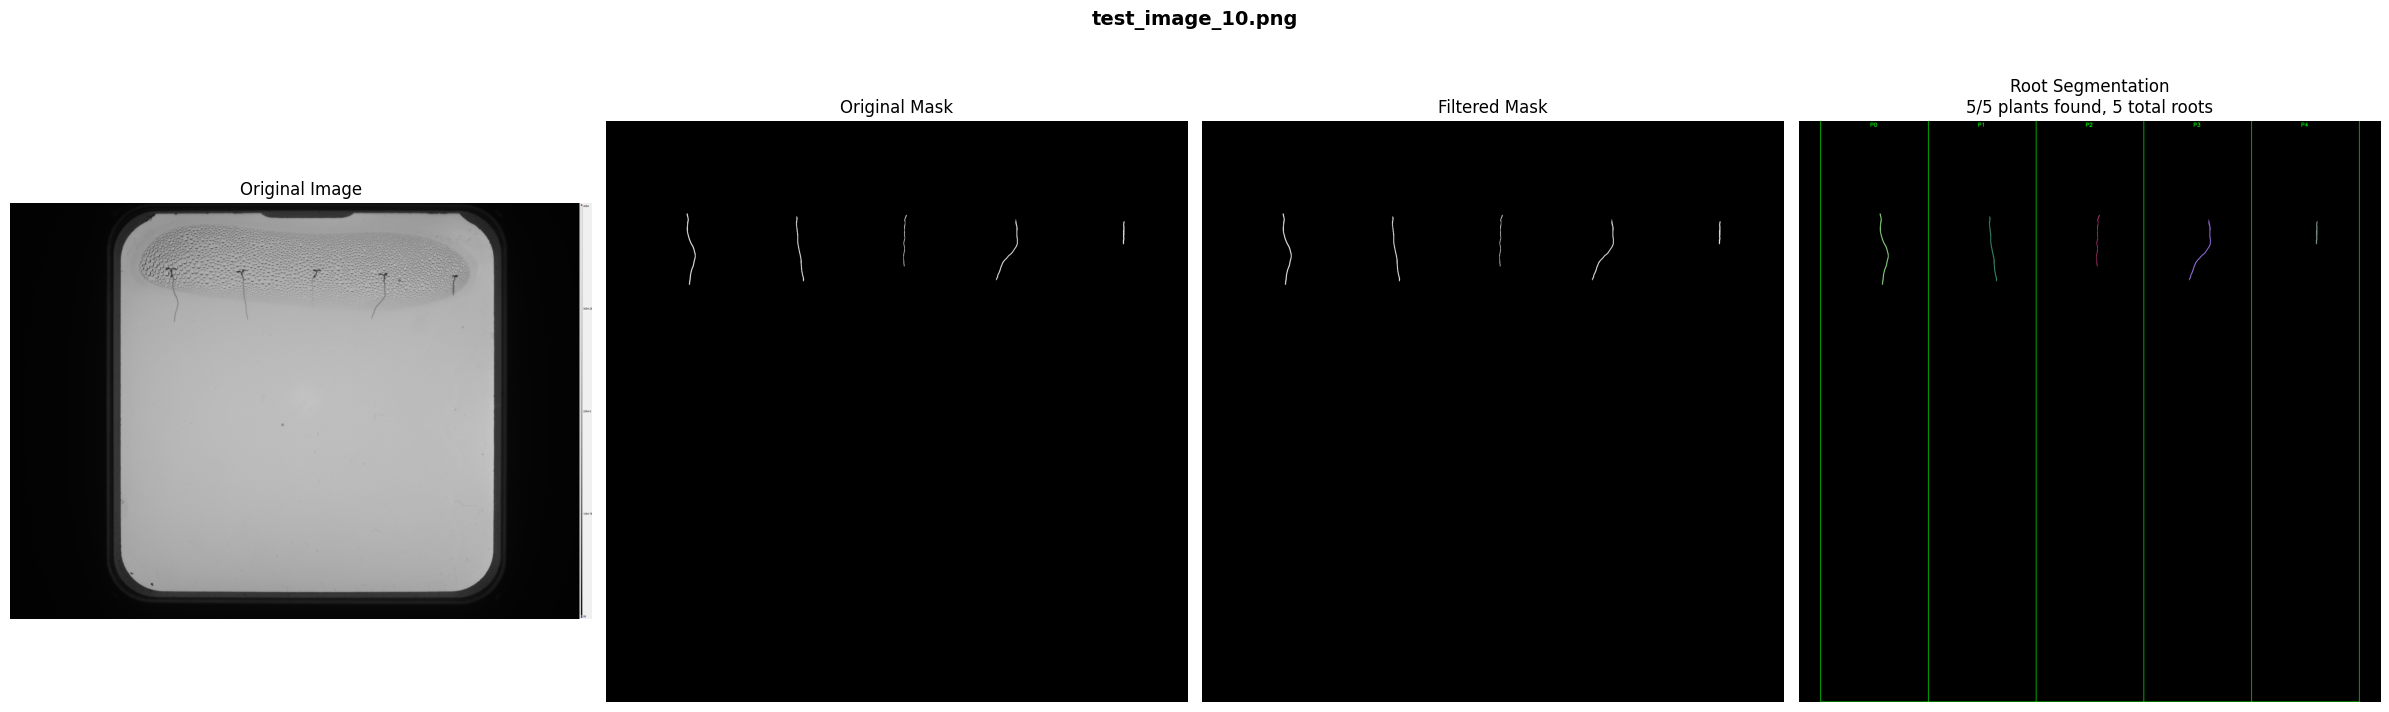


test_image_11.png:
  Found: 5/5 plants
    Plant 0: FOUND, 2 roots
    Plant 1: FOUND, 2 roots
    Plant 2: FOUND, 3 roots
    Plant 3: FOUND, 2 roots
    Plant 4: FOUND, 2 roots
  Total roots across all plants: 11
Saved visualization to segmentation_output_strict/visualizations/test_image_11_segmentation.png


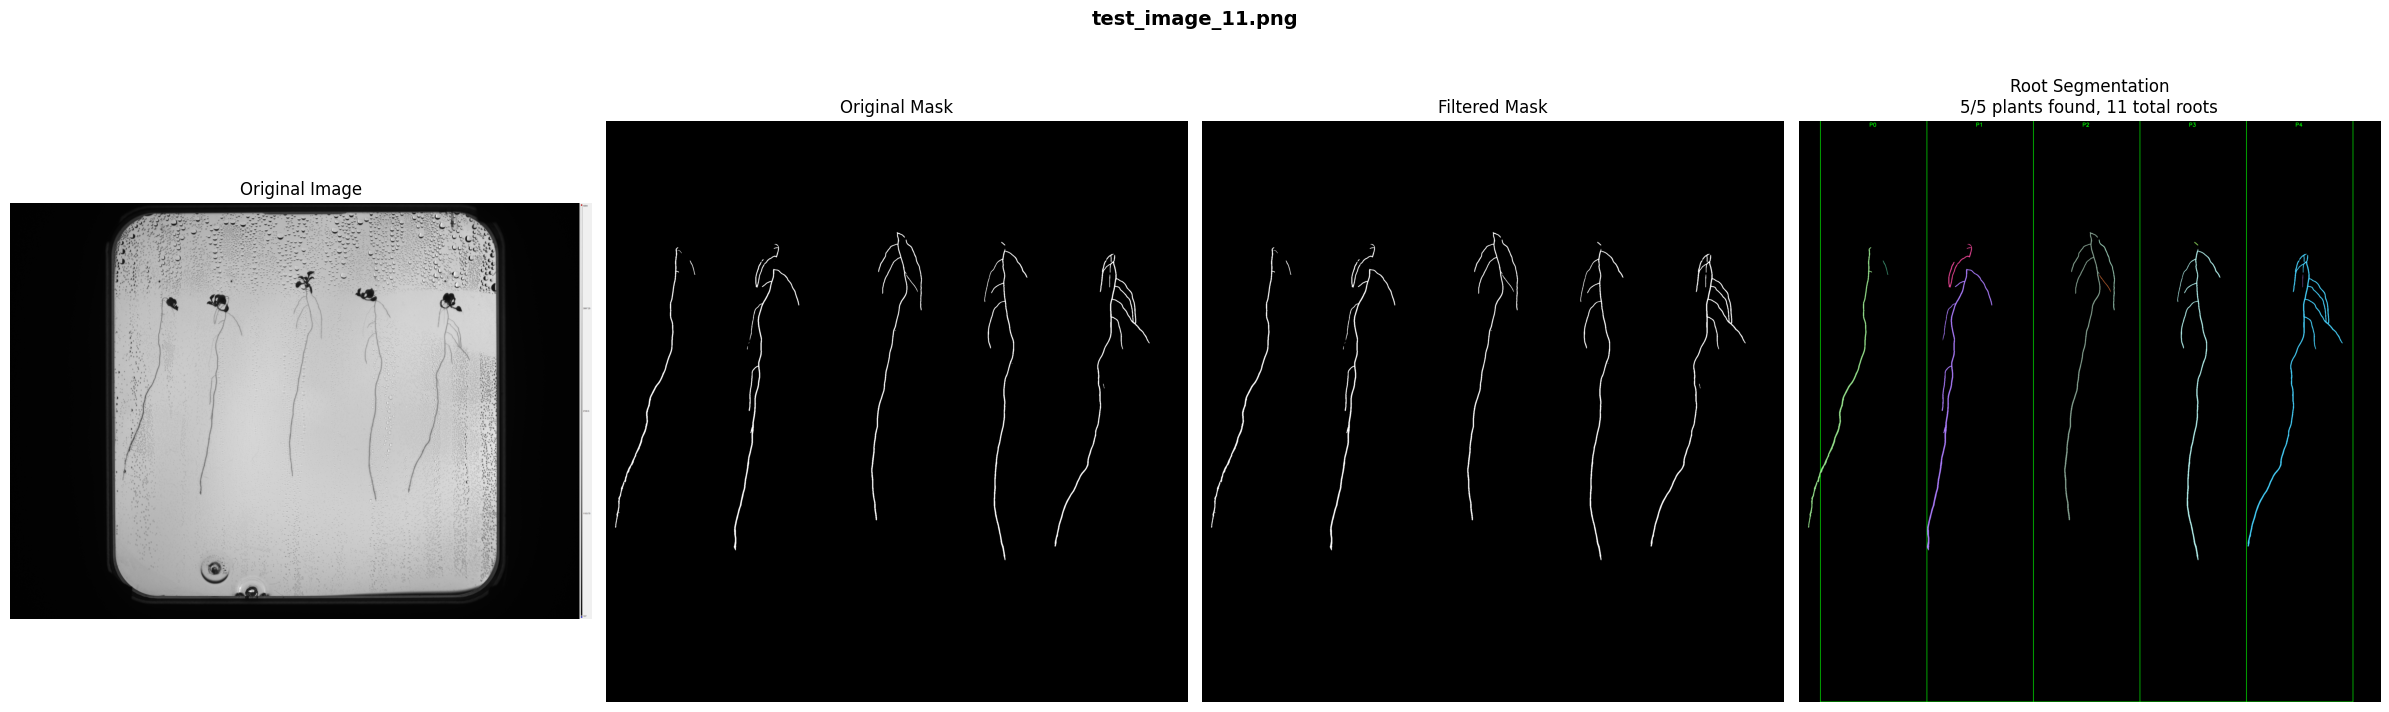


test_image_12.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_12_segmentation.png


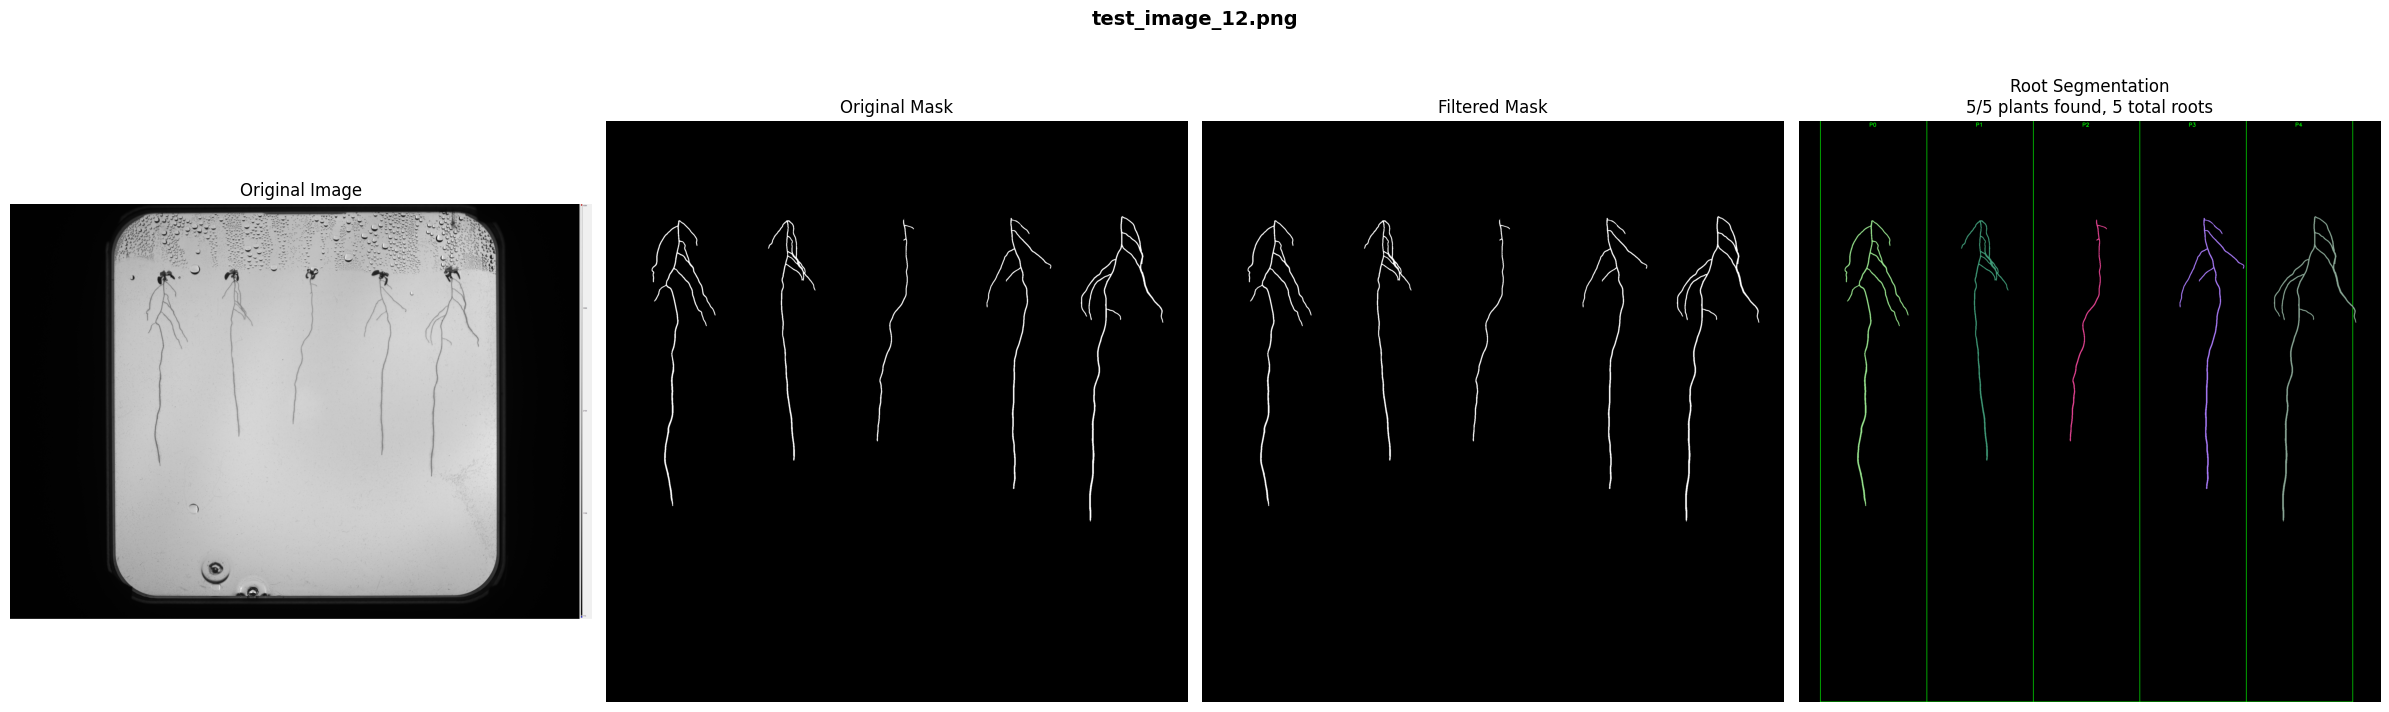


test_image_13.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_13_segmentation.png


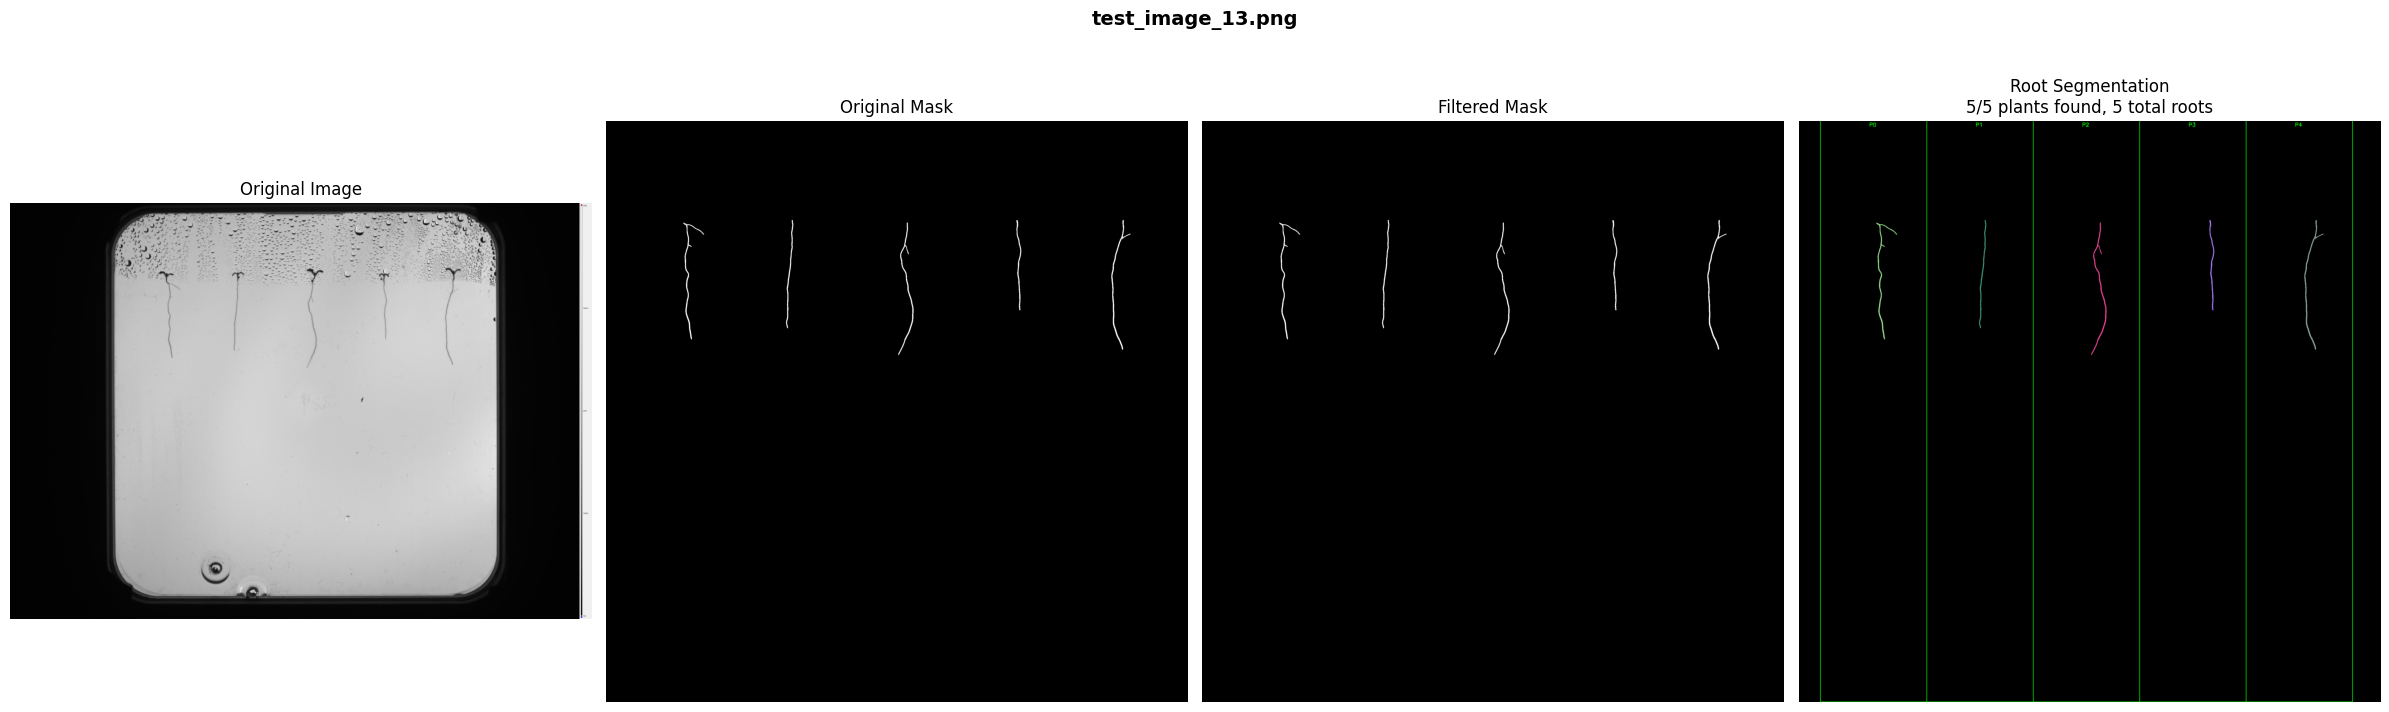


test_image_14.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_14_segmentation.png


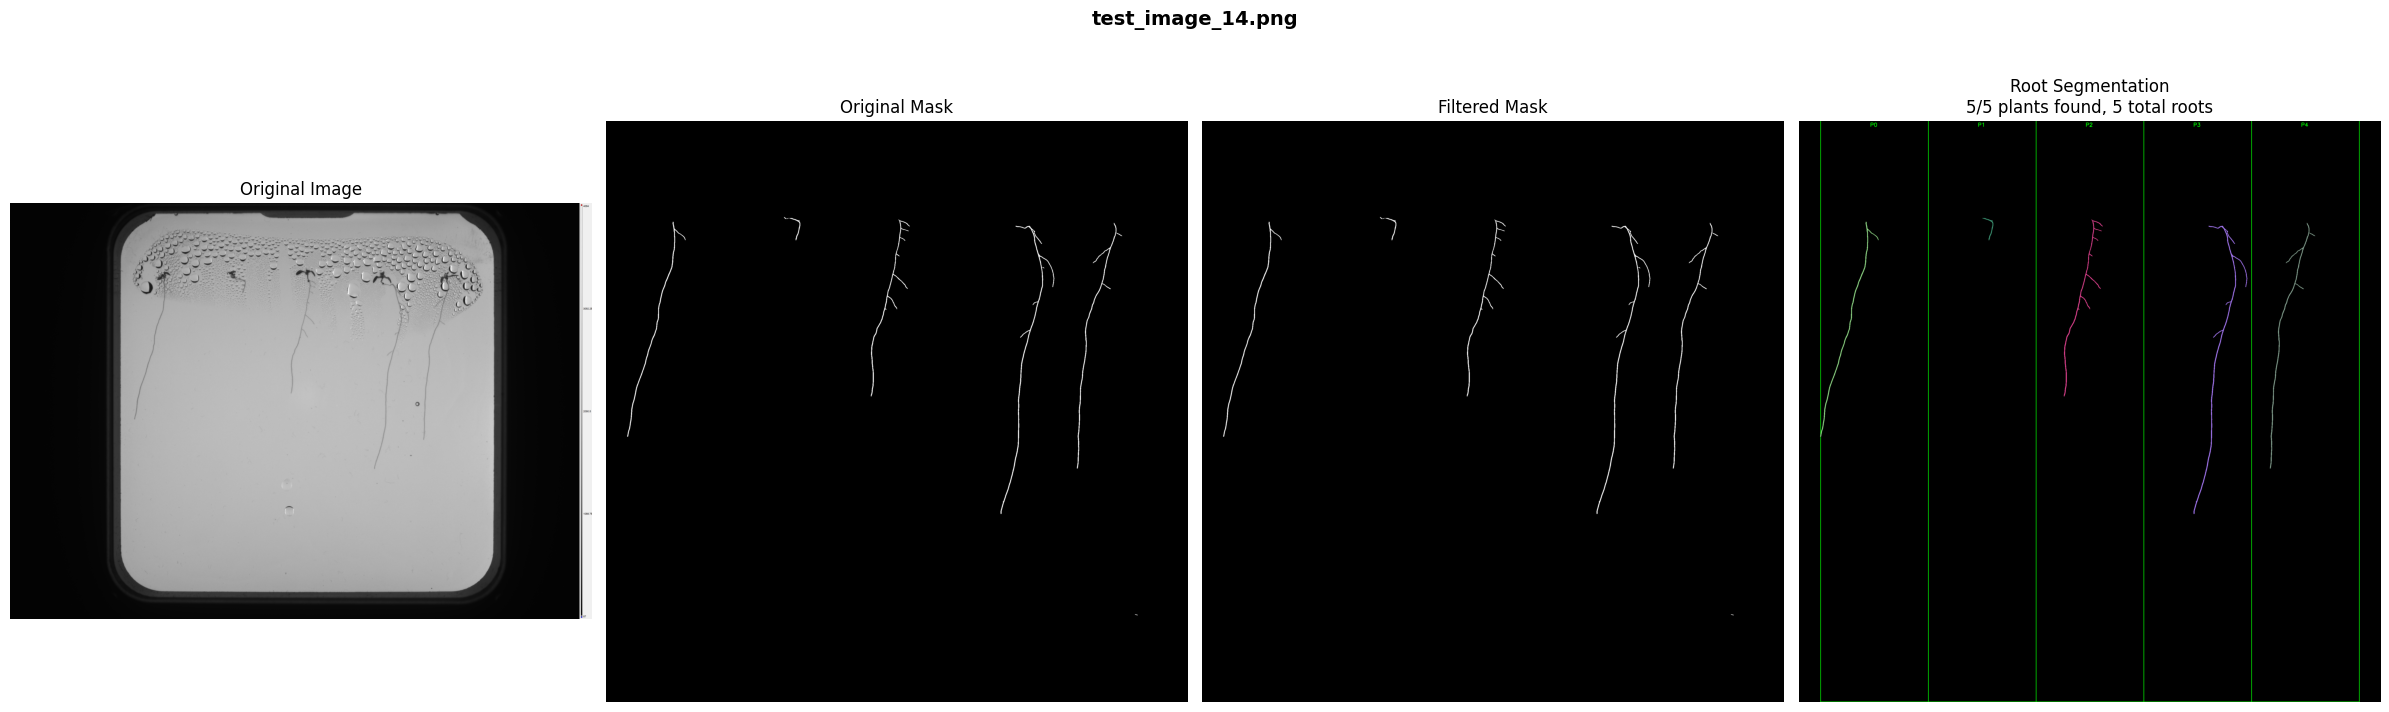


test_image_15.png:
  Found: 3/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: NOT FOUND
    Plant 2: FOUND, 1 roots
    Plant 3: NOT FOUND
    Plant 4: FOUND, 0 roots
  Total roots across all plants: 2
Saved visualization to segmentation_output_strict/visualizations/test_image_15_segmentation.png


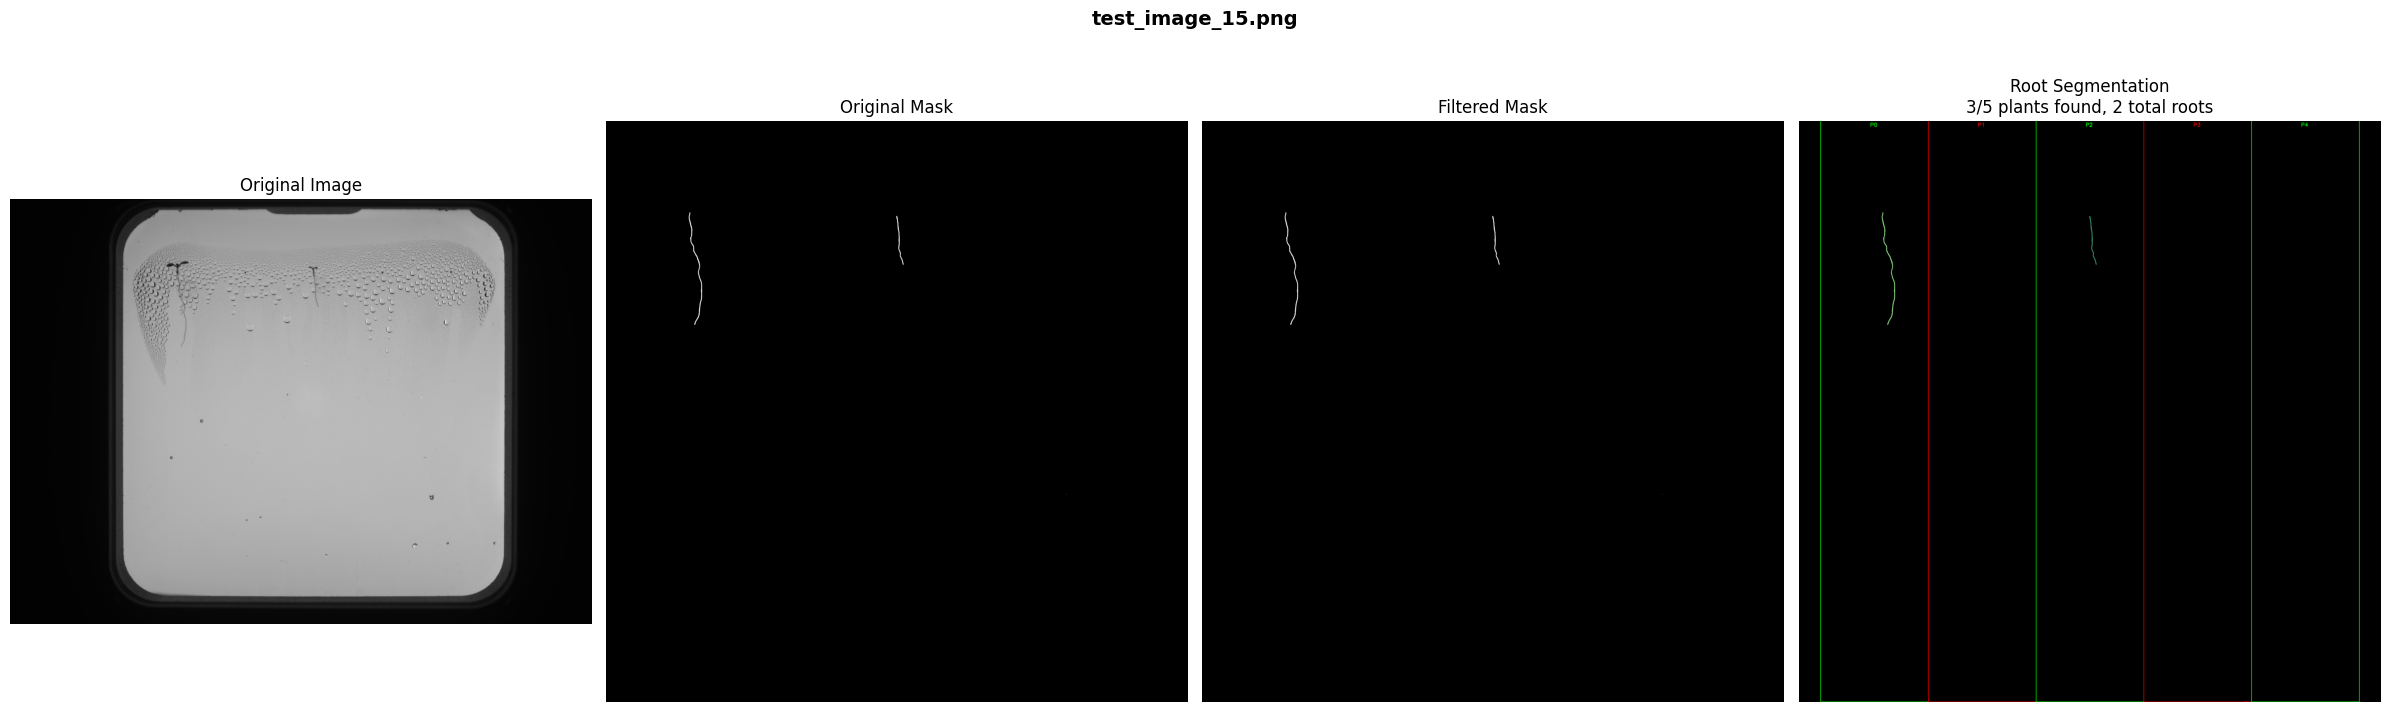


test_image_16.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_16_segmentation.png


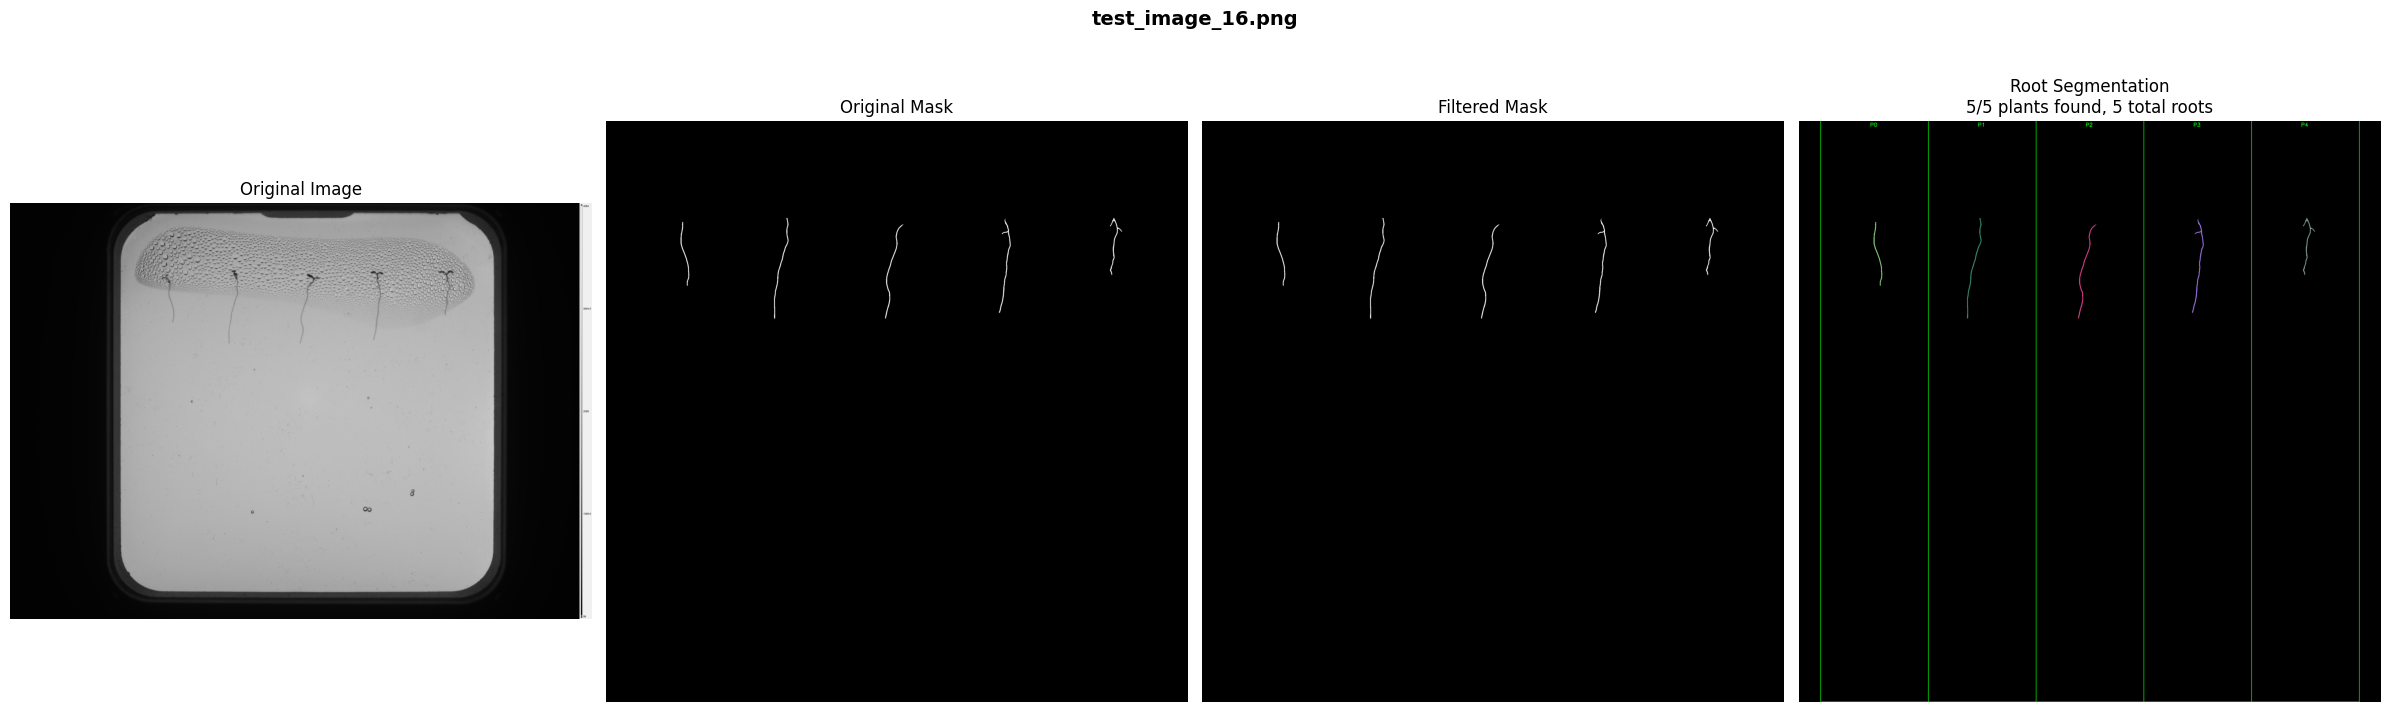


test_image_17.png:
  Found: 5/5 plants
    Plant 0: FOUND, 2 roots
    Plant 1: FOUND, 6 roots
    Plant 2: FOUND, 3 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 13
Saved visualization to segmentation_output_strict/visualizations/test_image_17_segmentation.png


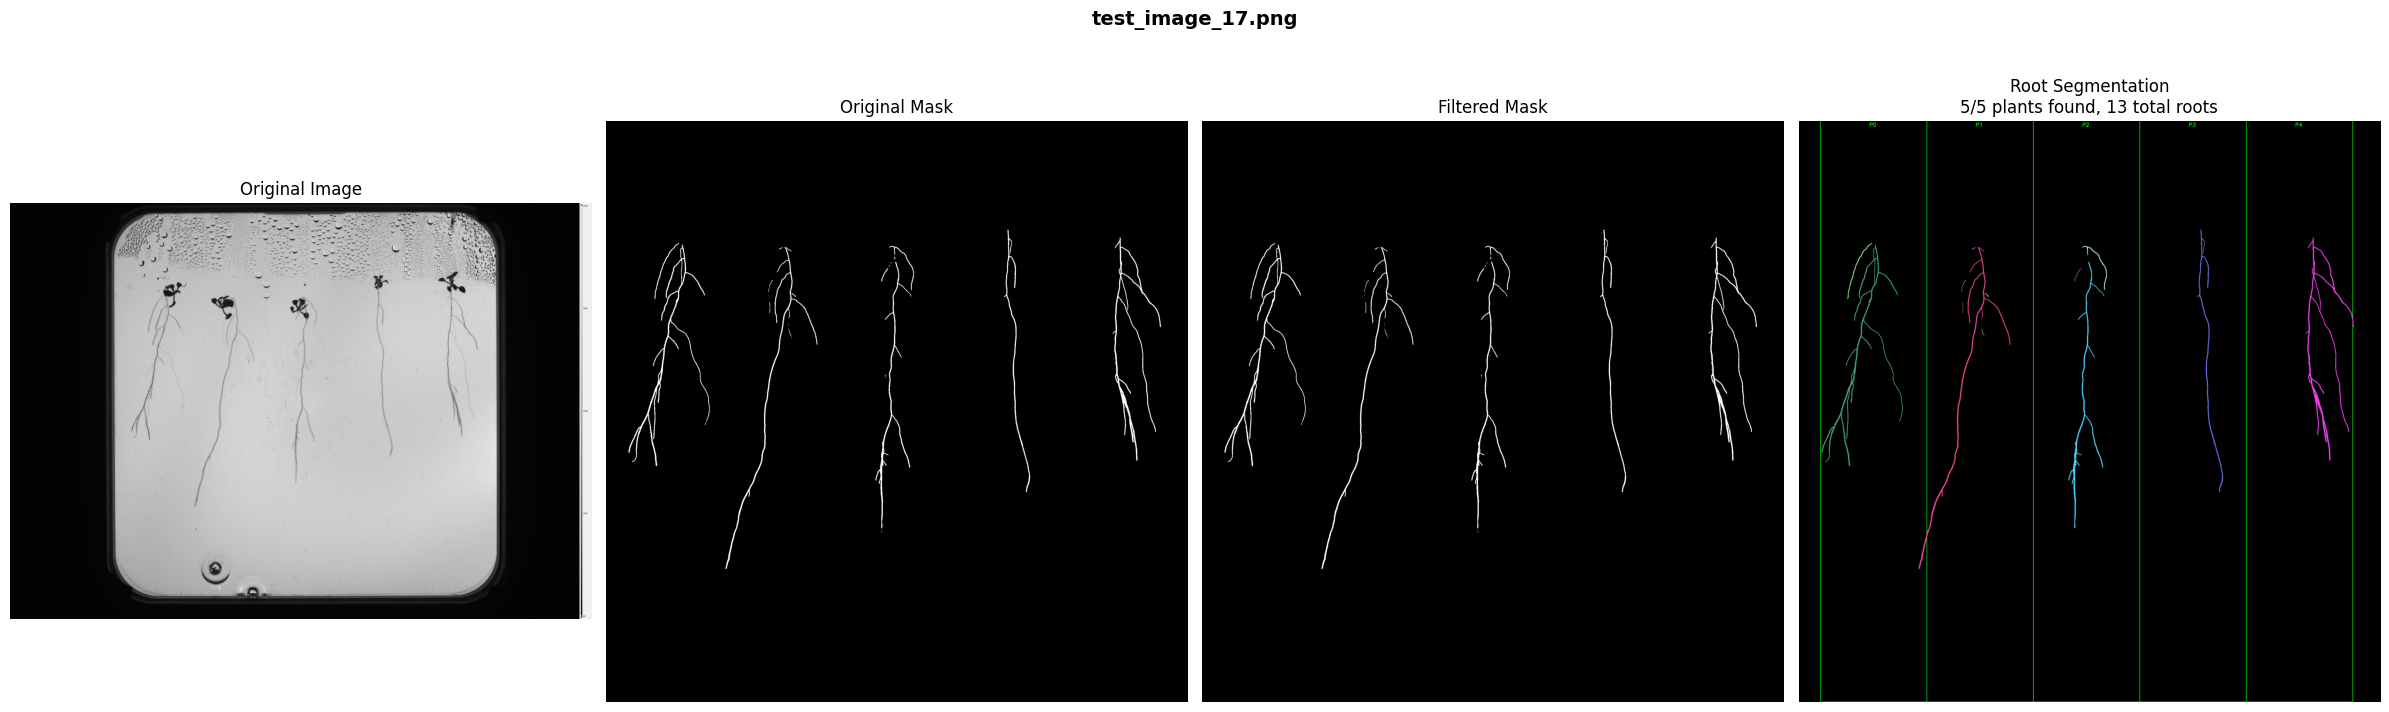


test_image_18.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 2 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 6
Saved visualization to segmentation_output_strict/visualizations/test_image_18_segmentation.png


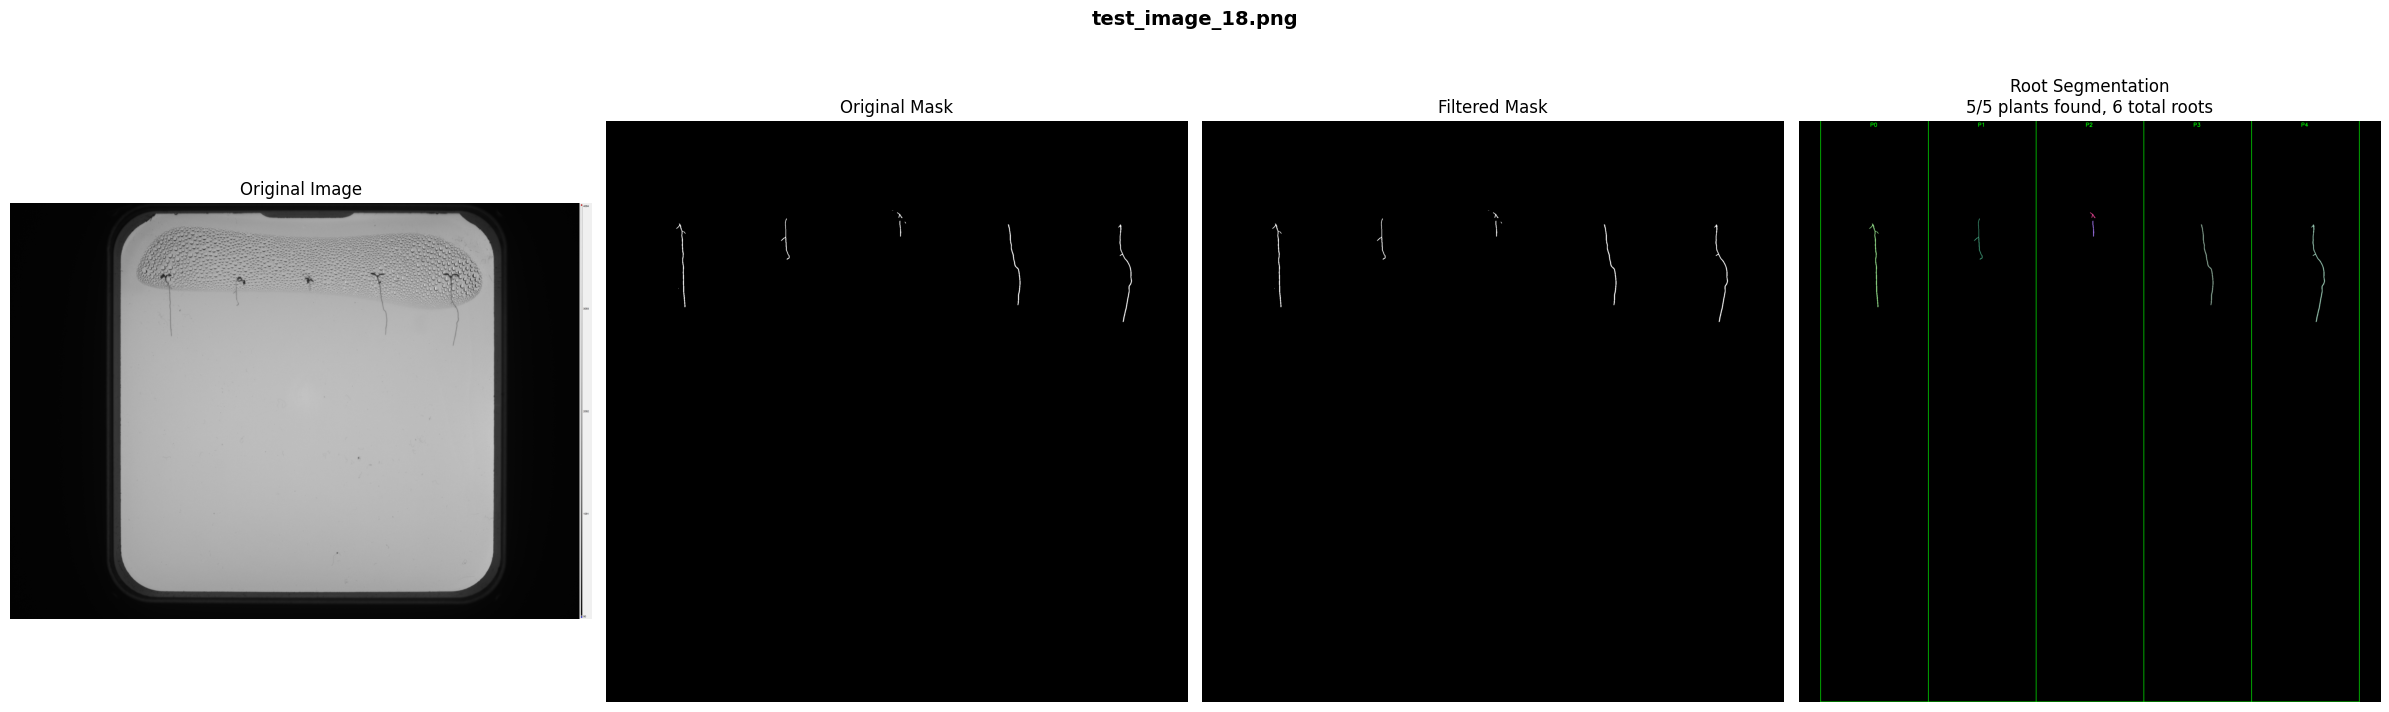


test_image_19.png:
  Found: 5/5 plants
    Plant 0: FOUND, 1 roots
    Plant 1: FOUND, 1 roots
    Plant 2: FOUND, 1 roots
    Plant 3: FOUND, 1 roots
    Plant 4: FOUND, 1 roots
  Total roots across all plants: 5
Saved visualization to segmentation_output_strict/visualizations/test_image_19_segmentation.png


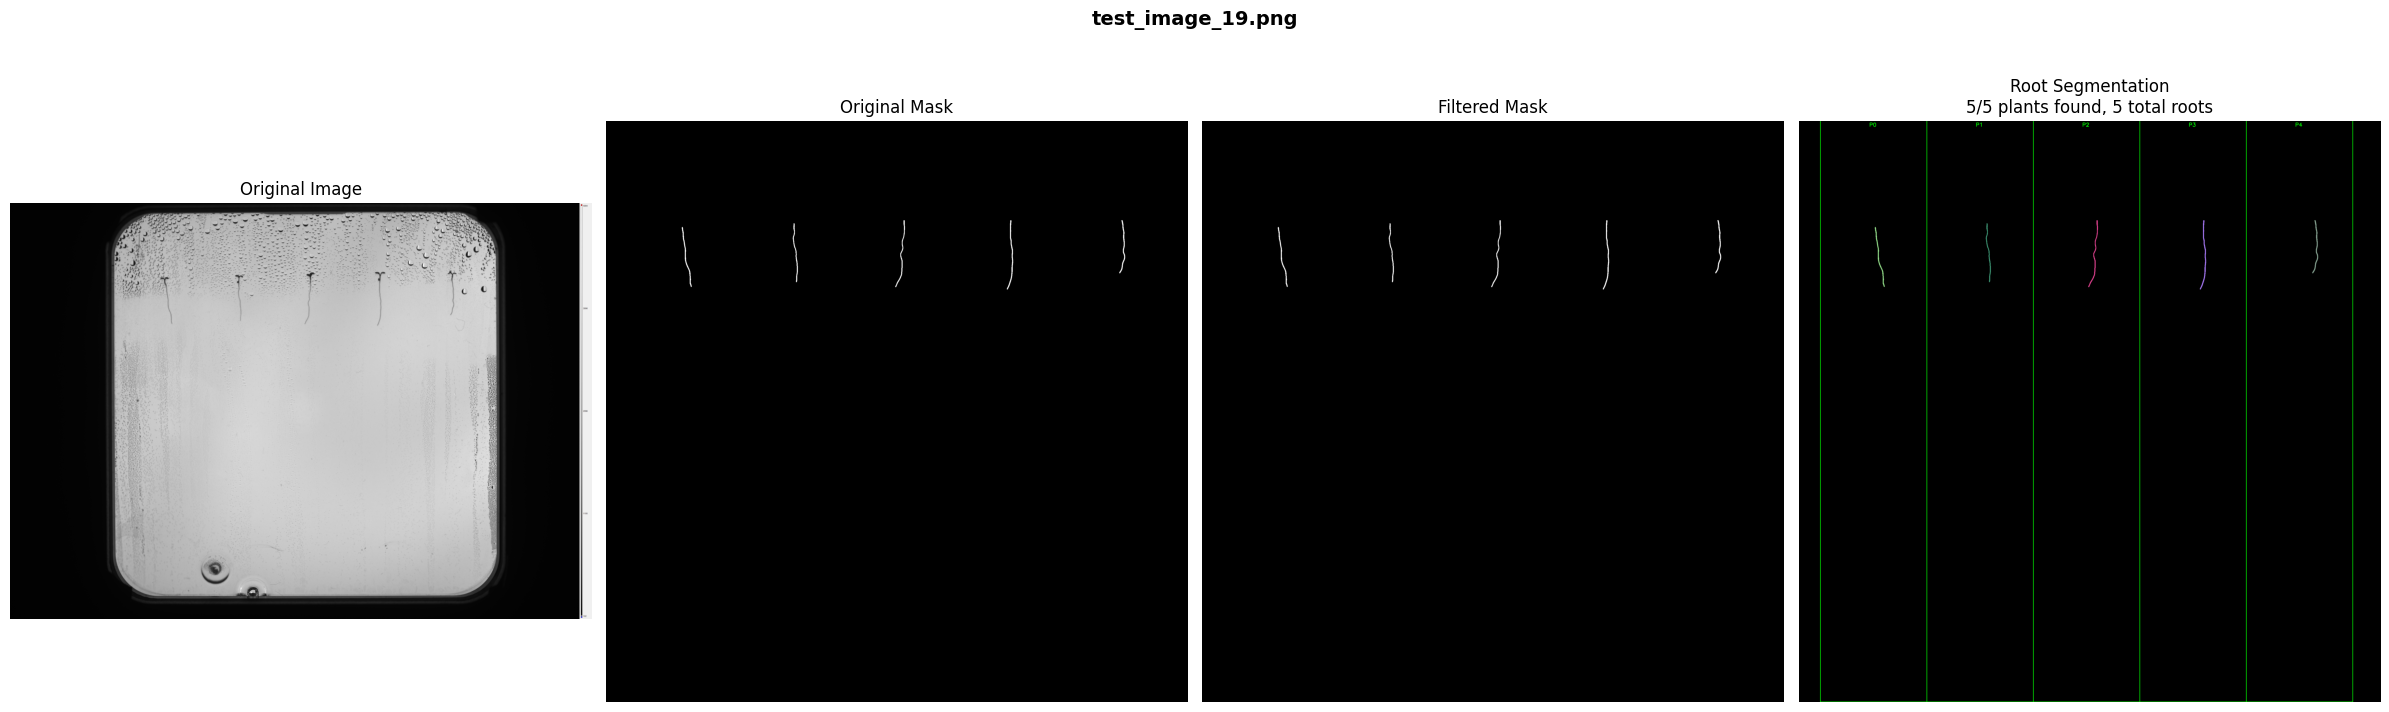

Segmentation data exported to segmentation_output_strict/visualizations/segmentation_data.txt

STEP 2: Saving individual plant files

Saving individual plants to segmentation_output_strict/individual_plants/
Format: mask
Note: All plant masks are full-sized (same as original image)

  Saved test_image_01_plant_1.png (1 roots, 10361 pixels)
  Saved test_image_01_plant_2.png (1 roots, 12292 pixels)
  Saved test_image_01_plant_3.png (plant not found - empty full-sized image)
  Saved test_image_01_plant_4.png (8 roots, 37907 pixels)
  Saved test_image_01_plant_5.png (1 roots, 29532 pixels)
  Saved test_image_02_plant_1.png (1 roots, 10861 pixels)
  Saved test_image_02_plant_2.png (2 roots, 12745 pixels)
  Saved test_image_02_plant_3.png (1 roots, 5985 pixels)
  Saved test_image_02_plant_4.png (1 roots, 6008 pixels)
  Saved test_image_02_plant_5.png (1 roots, 7051 pixels)
  Saved test_image_03_plant_1.png (1 roots, 193 pixels)
  Saved test_image_03_plant_2.png (1 roots, 587 pixels)
  Saved 

In [15]:
from root_segmentation import process_and_save_all

results_strict = process_and_save_all(
    images=load_all_images(),
    masks=load_all_masks(),
    output_base_dir='segmentation_output_strict',
    save_roots=True,
    roots_full_size=True,
    roots_validate=True,
)